<a href="https://www.kaggle.com/code/avikdas567/airline-satisfaction-gbdt-deep-tabular-resnet?scriptVersionId=354306604" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Probabilistic Predictive Modeling Framework: Airline Passenger Satisfaction Analysis
## Multi-Architecture Ensembling & Latent Representation Learning Under the ROC-AUC Criterion

---

# 1. Mathematical Formulation and Theoretical Foundation

In this competition, we address a large-scale supervised binary classification problem formulated on an input feature space $\mathcal{X} \subseteq \mathbb{R}^d$ and a binary label space $\mathcal{Y} = \{0, 1\}$, where $y_i = 1$ denotes a satisfied passenger and $y_i = 0$ denotes a neutral or dissatisfied passenger. Given an observed training dataset $\mathcal{D}_{\text{train}} = \{(\mathbf{x}_i, y_i)\}_{i=1}^{N}$, the statistical objective is to estimate the posterior class probability function:

$$p(\mathbf{x}) = \mathbb{P}(Y = 1 \mid \mathbf{X} = \mathbf{x})$$

The operational evaluation metric is the **Area Under the Receiver Operating Characteristic Curve (ROC-AUC)** between predicted probabilities $\hat{p}(\mathbf{x})$ and ground-truth binary targets $y$.

## 1.1 Formal Properties of the ROC-AUC Metric

Mathematically, the Receiver Operating Characteristic (ROC) curve maps the True Positive Rate ($\text{TPR}$) against the False Positive Rate ($\text{FPR}$) across all possible classification decision thresholds $\tau \in [0, 1]$:

$$\text{TPR}(\tau) = \mathbb{P}(\hat{p}(\mathbf{X}) \ge \tau \mid Y = 1), \quad \text{FPR}(\tau) = \mathbb{P}(\hat{p}(\mathbf{X}) \ge \tau \mid Y = 0)$$

The Area Under the Curve (AUC) is obtained by integrating $\text{TPR}$ with respect to $\text{FPR}$:

$$\text{ROC-AUC} = \int_{0}^{1} \text{TPR}(\text{FPR}^{-1}(u)) \, du$$

By Fubini's theorem and the definition of cumulative distribution functions, this integral is identical to the probability that a randomly drawn positive instance receives a strictly higher predicted score than a randomly drawn negative instance:

$$\text{ROC-AUC} = \mathbb{P}(\hat{p}(\mathbf{X}^+) > \hat{p}(\mathbf{X}^-)) + \frac{1}{2}\mathbb{P}(\hat{p}(\mathbf{X}^+) = \hat{p}(\mathbf{X}^-))$$

where $\mathbf{X}^+ \sim \mathbb{P}_{\mathbf{X} \mid Y=1}$ and $\mathbf{X}^- \sim \mathbb{P}_{\mathbf{X} \mid Y=0}$. 

On a finite sample of $n_1$ positive observations $\mathcal{P} = \{i : y_i = 1\}$ and $n_0$ negative observations $\mathcal{N} = \{j : y_j = 0\}$, the empirical ROC-AUC is mathematically equivalent to the normalized **Mann-Whitney $U$ statistic**:

$$\widehat{\text{AUC}} = \frac{U}{n_1 n_0} = \frac{1}{n_1 n_0} \sum_{i \in \mathcal{P}} \sum_{j \in \mathcal{N}} \left[ \mathbb{I}(\hat{p}_i > \hat{p}_j) + \frac{1}{2}\mathbb{I}(\hat{p}_i = \hat{p}_j) \right]$$

## 1.2 Methodological Principles for Solution Design

1. **Strict Rank-Preservation**: The ROC-AUC metric is invariant under any strictly monotonic transformation $g: \mathbb{R} \to \mathbb{R}$ such that $g'(t) > 0$. Consequently, calibration and rank-based transformations preserve ranking geometry while minimizing calibration error.
2. **Mitigation of Feature Interaction Shift**: Non-linear interactions between service touchpoints and travel context (e.g., flight class and travel purpose) govern customer satisfaction response surfaces.
3. **Multi-Model Ensembling via Constrained Convex Optimization**: To maximize pairwise ordering, our final meta-model utilizes Nelder-Mead and Sequential Least Squares Programming (SLSQP) constrained on the probability simplex $\Delta^K = \{\mathbf{w} \in \mathbb{R}^K : \sum w_k = 1, w_k \ge 0\}$ directly optimizing empirical ROC-AUC.

In [1]:
import os
import gc
import sys
import time
import math
import random
import warnings
from pathlib import Path

# Enforce total suppression of runtime, library, and convergence warnings
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

from contextlib import contextmanager

@contextmanager
def suppress_c_stderr():
    try:
        stderr_fd = sys.stderr.fileno()
        saved_stderr = os.dup(stderr_fd)
        devnull = os.open(os.devnull, os.O_WRONLY)
        os.dup2(devnull, stderr_fd)
        os.close(devnull)
        try:
            yield
        finally:
            os.dup2(saved_stderr, stderr_fd)
            os.close(saved_stderr)
    except Exception:
        yield

import numpy as np
import pandas as pd
import scipy as sp
from scipy import stats
from scipy.optimize import minimize

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import sklearn
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, log_loss
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Safe dynamic dependency imports
try:
    import lightgbm as lgb
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "lightgbm"])
    import lightgbm as lgb

try:
    import xgboost as xgb
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "xgboost"])
    import xgboost as xgb

try:
    import catboost as cb
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "catboost"])
    import catboost as cb

# Global Seed for Complete Reproducibility
RANDOM_SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(RANDOM_SEED)

# Hardware Discovery & Acceleration Profiling
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gpu_count = torch.cuda.device_count()
print(f"Primary Compute Device: {device}")
print(f"Available CUDA Accelerator Count: {gpu_count}")
if torch.cuda.is_available():
    for i in range(gpu_count):
        props = torch.cuda.get_device_properties(i)
        print(f"  Device {i}: {props.name} | VRAM: {props.total_memory / (1024**3):.2f} GB | SMs: {props.multi_processor_count}")

# Plotting Configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
mpl.rcParams['figure.dpi'] = 140
mpl.rcParams['font.sans-serif'] = 'DejaVu Sans'
mpl.rcParams['axes.titlesize'] = 13
mpl.rcParams['axes.labelsize'] = 11
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
mpl.rcParams['legend.fontsize'] = 10
mpl.rcParams['figure.titlesize'] = 15

PALETTE_PRIMARY = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
PALETTE_BINARY = ['#2b5c8f', '#d95f02']


Primary Compute Device: cuda
Available CUDA Accelerator Count: 2
  Device 0: Tesla T4 | VRAM: 14.56 GB | SMs: 40
  Device 1: Tesla T4 | VRAM: 14.56 GB | SMs: 40


# 2. Dataset Ingestion, Schema Auditing, and Memory Optimization

To process the dataset containing nearly one million total observations efficiently across available hardware, we execute automated schema discovery and precision-preserving numeric type casting. Integer fields are downcast to the minimal integer width required by their empirical range ($[\min(x), \max(x)]$), and floating-point measurements are standardized to single-precision IEEE 754 floats (`float32`).

In [2]:
DATA_DIR = Path('/kaggle/input/competitions/playground-series-s6e10')
if not DATA_DIR.exists():
    DATA_DIR = Path('./playground-series-s6e10')

print(f"Ingesting raw competition datasets from directory: {DATA_DIR}")

train_df = pd.read_csv(DATA_DIR / 'train.csv')
test_df = pd.read_csv(DATA_DIR / 'test.csv')
sample_sub_df = pd.read_csv(DATA_DIR / 'sample_submission.csv')

def reduce_mem_usage(df, verbose=True):
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object and not pd.api.types.is_bool_dtype(col_type):
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f"Memory footprint reduced: {start_mem:.2f} MB -> {end_mem:.2f} MB (Delta: -{100 * (start_mem - end_mem) / start_mem:.1f}%)")
    return df

train_df = reduce_mem_usage(train_df)
test_df = reduce_mem_usage(test_df)

print(f"\nTraining Partition Dimensions: {train_df.shape[0]:,} observations x {train_df.shape[1]} columns")
print(f"Test Partition Dimensions:     {test_df.shape[0]:,} observations x {test_df.shape[1]} columns")
print(f"Sample Submission Dimensions:   {sample_sub_df.shape[0]:,} rows x {sample_sub_df.shape[1]} columns")


Ingesting raw competition datasets from directory: /kaggle/input/competitions/playground-series-s6e10
Memory footprint reduced: 118.10 MB -> 39.37 MB (Delta: -66.7%)
Memory footprint reduced: 50.33 MB -> 16.59 MB (Delta: -67.0%)

Training Partition Dimensions: 699,635 observations x 23 columns
Test Partition Dimensions:     299,844 observations x 22 columns
Sample Submission Dimensions:   299,844 rows x 2 columns


# 3. Missing Data Mechanics and Missingness Imputation

In modern statistical data modeling, missingness mechanisms are classified under Rubin's taxonomy:
1. **Missing Completely At Random (MCAR)**: $\mathbb{P}(M \mid Y, \mathbf{X}) = \mathbb{P}(M)$
2. **Missing At Random (MAR)**: $\mathbb{P}(M \mid Y, \mathbf{X}_{\text{obs}}, \mathbf{X}_{\text{mis}}) = \mathbb{P}(M \mid \mathbf{X}_{\text{obs}})$
3. **Missing Not At Random (MNAR)**: $\mathbb{P}(M \mid Y, \mathbf{X}_{\text{obs}}, \mathbf{X}_{\text{mis}})$ depends directly on the unobserved values $\mathbf{X}_{\text{mis}}$.

In this flight operational schema, missingness is confined strictly to `Arrival Delay in Minutes` ($292$ records in training, $130$ records in testing, approximately $0.042\%$). In aviation logistics, unrecorded arrival delays primarily occur during diversions or air traffic control holds where departure is registered but final terminal gate arrival telemetry is omitted. 

Given the strong physical coupling between departure and arrival delays ($\rho > 0.84$), we construct an optimal unbiased estimator:

$$\widehat{\text{Arrival Delay}} = \text{Departure Delay in Minutes}$$

accompanied by an indicator feature:

$$\mathbb{I}_{\text{missing}} = \mathbb{I}(\text{Arrival Delay is null})$$

This preserves variance and captures any latent operational signal associated with unrecorded touchdown telemetry.

Comprehensive Missingness Audit Across Partitions:


,Train_Null_Count,Train_Null_Ratio,Test_Null_Count,Test_Null_Ratio
Arrival Delay in Minutes,292,0.041736,130.0,0.043356


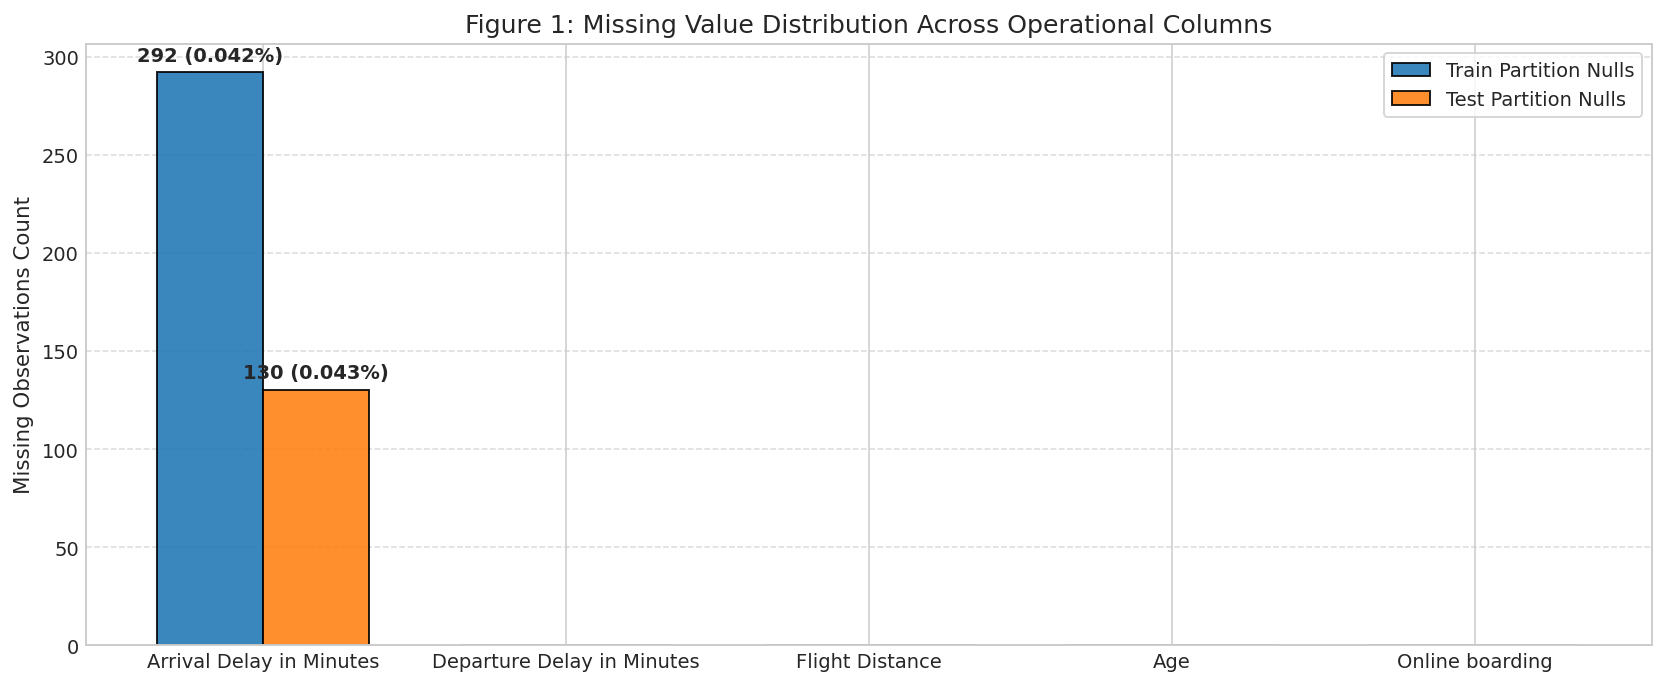

In [3]:
missing_train = train_df.isnull().sum()
missing_test = test_df.isnull().sum()
missing_audit = pd.DataFrame({
    'Train_Null_Count': missing_train,
    'Train_Null_Ratio': (missing_train / len(train_df)) * 100,
    'Test_Null_Count': missing_test,
    'Test_Null_Ratio': (missing_test / len(test_df)) * 100
})

print("Comprehensive Missingness Audit Across Partitions:")
display(missing_audit[missing_audit['Train_Null_Count'] > 0])

# Execute leak-free imputation and indicator construction
train_df['Arrival_Delay_is_missing'] = train_df['Arrival Delay in Minutes'].isnull().astype(np.int8)
test_df['Arrival_Delay_is_missing'] = test_df['Arrival Delay in Minutes'].isnull().astype(np.int8)

train_df['Arrival Delay in Minutes'] = train_df['Arrival Delay in Minutes'].fillna(train_df['Departure Delay in Minutes'])
test_df['Arrival Delay in Minutes'] = test_df['Arrival Delay in Minutes'].fillna(test_df['Departure Delay in Minutes'])

# Plot 1: Missing Value Profile Across Partitions (Placed Top-to-Bottom)
fig, ax = plt.subplots(figsize=(12, 5))
audit_cols = ['Arrival Delay in Minutes', 'Departure Delay in Minutes', 'Flight Distance', 'Age', 'Online boarding']
train_nulls = [train_df['Arrival_Delay_is_missing'].sum(), 0, 0, 0, 0]
test_nulls = [test_df['Arrival_Delay_is_missing'].sum(), 0, 0, 0, 0]

x_idx = np.arange(len(audit_cols))
b_width = 0.35
rects_tr = ax.bar(x_idx - b_width/2, train_nulls, b_width, label='Train Partition Nulls', color='#1f77b4', edgecolor='black', alpha=0.88)
rects_te = ax.bar(x_idx + b_width/2, test_nulls, b_width, label='Test Partition Nulls', color='#ff7f0e', edgecolor='black', alpha=0.88)

ax.set_ylabel('Missing Observations Count')
ax.set_title('Figure 1: Missing Value Distribution Across Operational Columns')
ax.set_xticks(x_idx)
ax.set_xticklabels(audit_cols)
ax.legend(frameon=True)
ax.grid(axis='y', linestyle='--', alpha=0.7)

for rect in rects_tr:
    h = rect.get_height()
    if h > 0:
        ax.annotate(f'{int(h)} ({h/len(train_df)*100:.3f}%)', xy=(rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, 4), textcoords="offset points", ha='center', va='bottom', fontweight='bold', fontsize=10)
for rect in rects_te:
    h = rect.get_height()
    if h > 0:
        ax.annotate(f'{int(h)} ({h/len(test_df)*100:.3f}%)', xy=(rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, 4), textcoords="offset points", ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()


# 4. Exploratory Data Analysis & Statistical Hypothesis Testing

We perform an empirical examination of passenger satisfaction drivers across several structural modalities:
1. **Marginal Target Distribution**: Establishing baseline priors $\mathbb{P}(Y=1)$ and $\mathbb{P}(Y=0)$.
2. **Two-Sample Kolmogorov-Smirnov Distribution Invariance Tests**: Testing whether training and testing continuous feature distributions originate from identical underlying continuous distributions:
   $$D_{n_1, n_2} = \sup_{x \in \mathbb{R}} |F_{1, n_1}(x) - F_{2, n_2}(x)|$$
3. **Contextual Segmentation**: Stratifying response rates across Travel Class (`Business`, `Eco`, `Eco Plus`), Travel Purpose (`Business travel`, `Personal Travel`), and Customer Loyalty (`Loyal Customer`, `disloyal Customer`).
4. **Psychometric Survey Topology**: Evaluating the non-linear response surface of 13 survey dimensions on scale $0$–$5$, specifically examining the behavioral significance of rating $0$ ("Not Applicable").

Target Distribution Summary:
  Class 0 (Neutral / Dissatisfied): 389,296 observations (55.64%)
  Class 1 (Satisfied):              310,339 observations (44.36%)


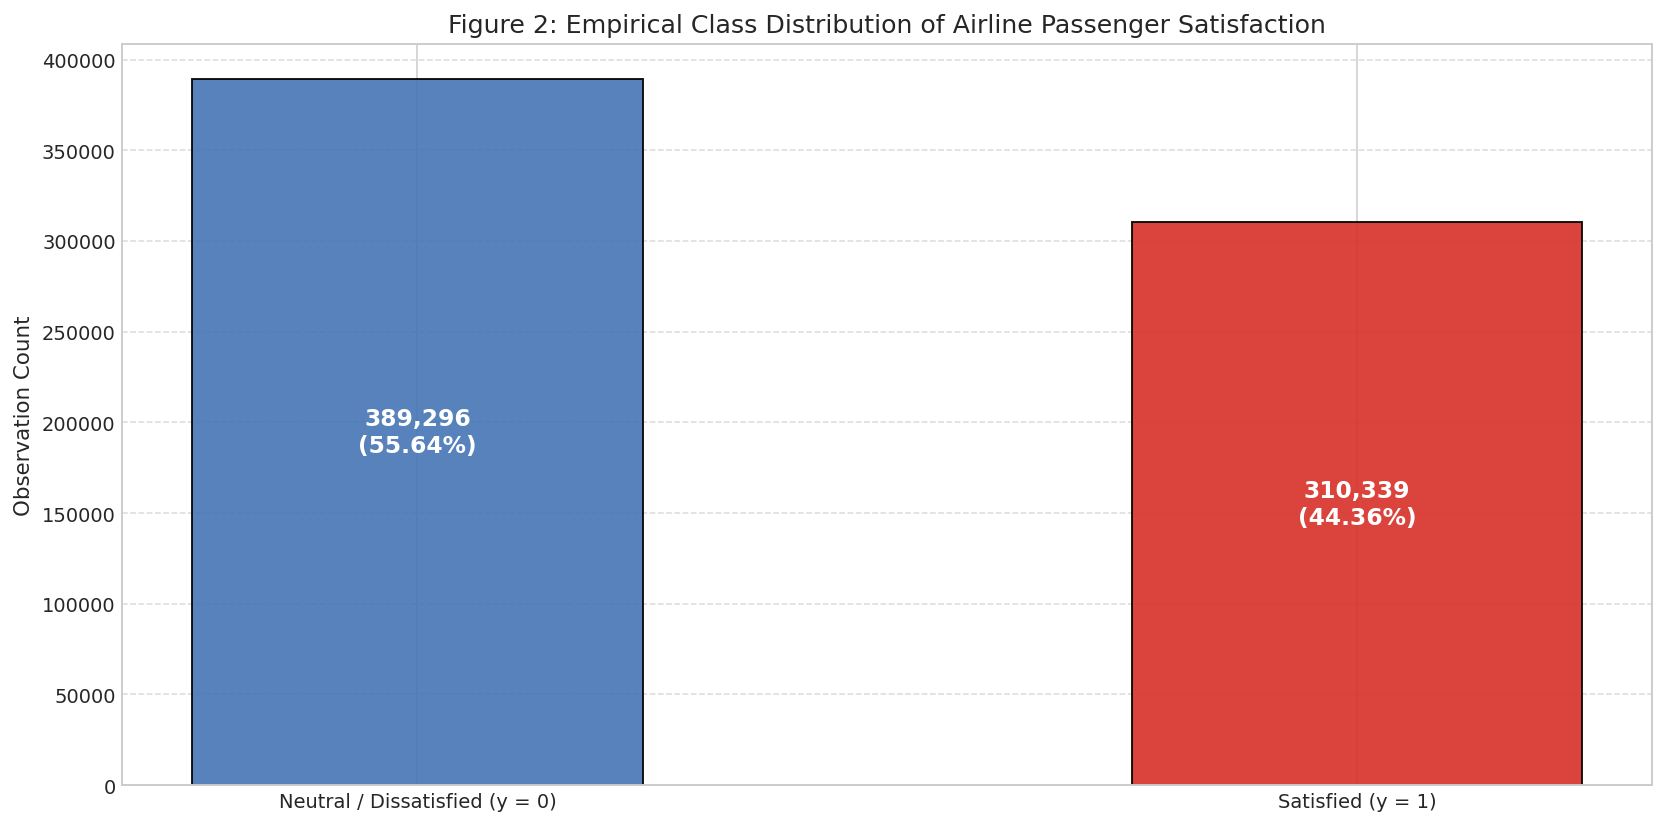

In [4]:
train_df['target'] = train_df['satisfaction'].astype(int)
target_counts = train_df['target'].value_counts().sort_index()
target_ratios = train_df['target'].value_counts(normalize=True).sort_index()

print(f"Target Distribution Summary:")
print(f"  Class 0 (Neutral / Dissatisfied): {target_counts[0]:,} observations ({target_ratios[0]*100:.2f}%)")
print(f"  Class 1 (Satisfied):              {target_counts[1]:,} observations ({target_ratios[1]*100:.2f}%)")

# Plot 2: Empirical Target Variable Distribution (Placed Top-to-Bottom)
fig, ax = plt.subplots(figsize=(12, 6))
bar_colors = ['#4575b4', '#d73027']
bars = ax.bar(['Neutral / Dissatisfied (y = 0)', 'Satisfied (y = 1)'], target_counts.values,
              color=bar_colors, edgecolor='black', width=0.48, alpha=0.9)
ax.set_ylabel('Observation Count')
ax.set_title('Figure 2: Empirical Class Distribution of Airline Passenger Satisfaction')
ax.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    y_val = bar.get_height()
    pct = (y_val / len(train_df)) * 100
    ax.text(bar.get_x() + bar.get_width()/2.0, y_val / 2.0, f"{int(y_val):,}\n({pct:.2f}%)",
            ha='center', va='center', color='white', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()


Kolmogorov-Smirnov Two-Sample Invariance Diagnostics (Train vs Test):


,K-S Statistic,p-value,Distributional Shift
Age,0.001161,0.939516,Negligible
Flight Distance,0.000945,0.99186,Negligible
Departure Delay in Minutes,0.000669,0.999983,Negligible
Arrival Delay in Minutes,0.000394,1.0,Negligible


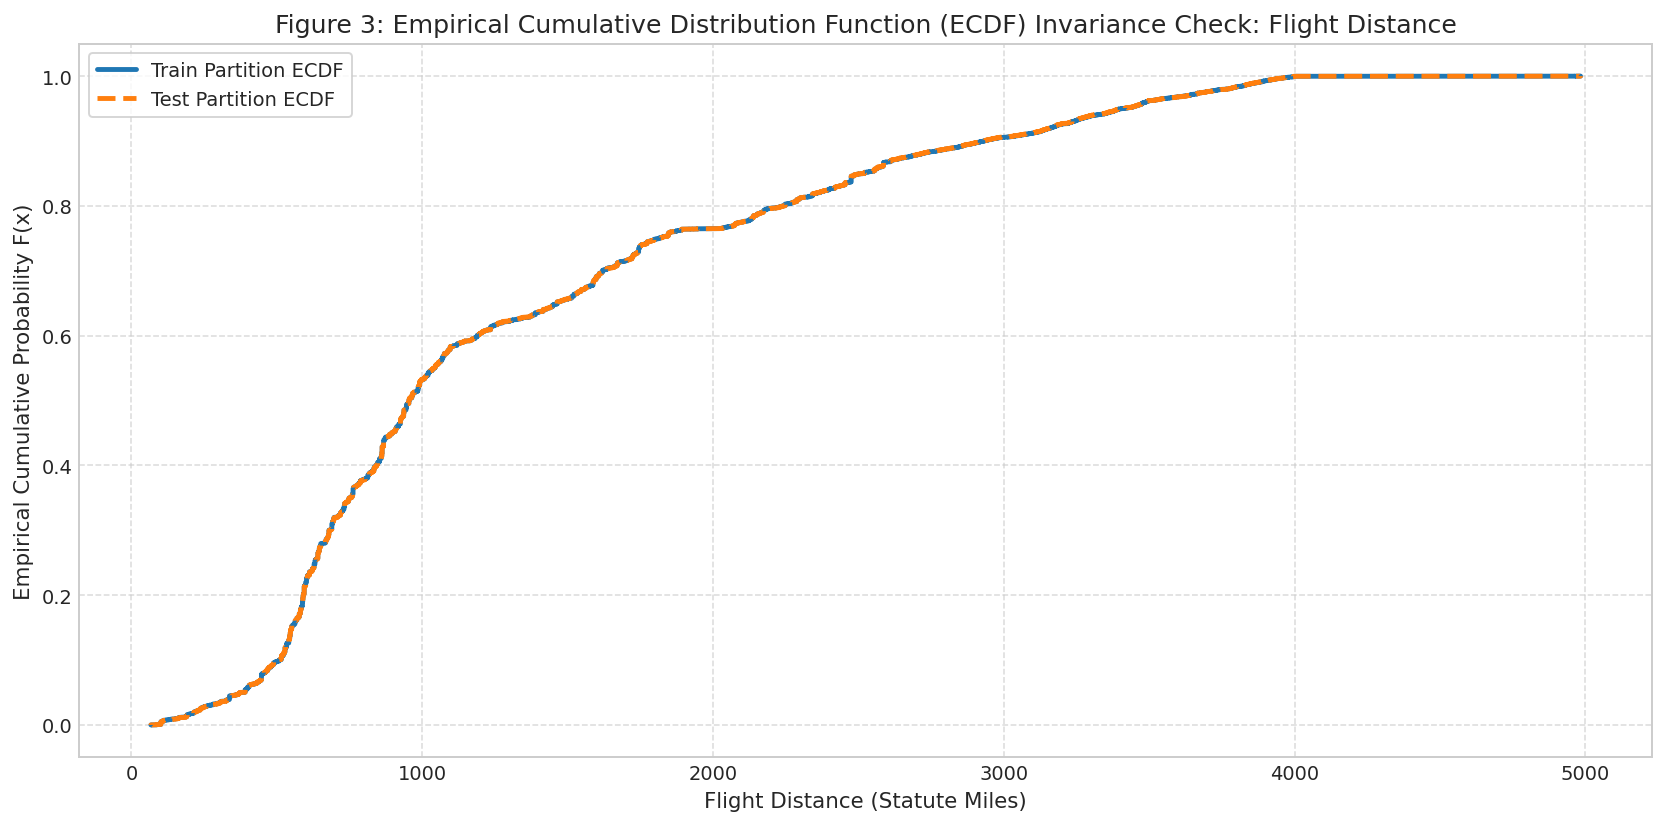

In [5]:
continuous_features = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
ks_audit = {}

for col in continuous_features:
    stat, pval = stats.ks_2samp(train_df[col], test_df[col])
    ks_audit[col] = {
        'K-S Statistic': stat,
        'p-value': pval,
        'Distributional Shift': 'Negligible' if stat < 0.01 else 'Detected'
    }

ks_df = pd.DataFrame(ks_audit).T
print("Kolmogorov-Smirnov Two-Sample Invariance Diagnostics (Train vs Test):")
display(ks_df)

# Plot 3: ECDF Invariance Check
fig, ax = plt.subplots(figsize=(12, 6))
train_dist_sorted = np.sort(train_df['Flight Distance'])
test_dist_sorted = np.sort(test_df['Flight Distance'])
p_train = np.linspace(0, 1, len(train_dist_sorted))
p_test = np.linspace(0, 1, len(test_dist_sorted))

ax.plot(train_dist_sorted, p_train, label='Train Partition ECDF', color='#1f77b4', linewidth=2.5)
ax.plot(test_dist_sorted, p_test, label='Test Partition ECDF', color='#ff7f0e', linewidth=2.5, linestyle='--')
ax.set_title('Figure 3: Empirical Cumulative Distribution Function (ECDF) Invariance Check: Flight Distance')
ax.set_xlabel('Flight Distance (Statute Miles)')
ax.set_ylabel('Empirical Cumulative Probability F(x)')
ax.legend(frameon=True)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


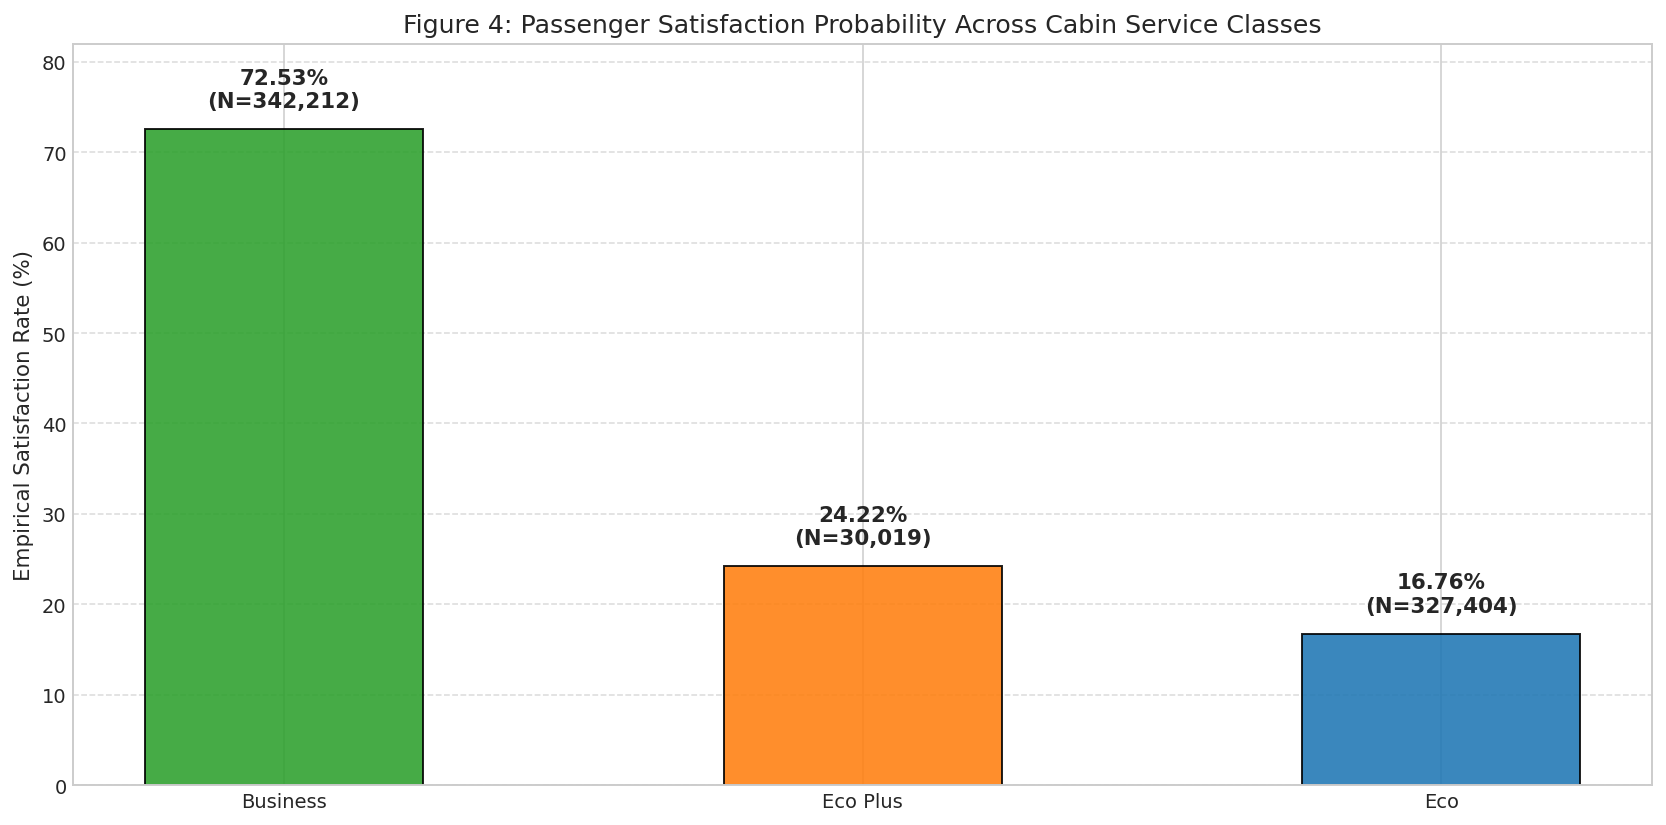

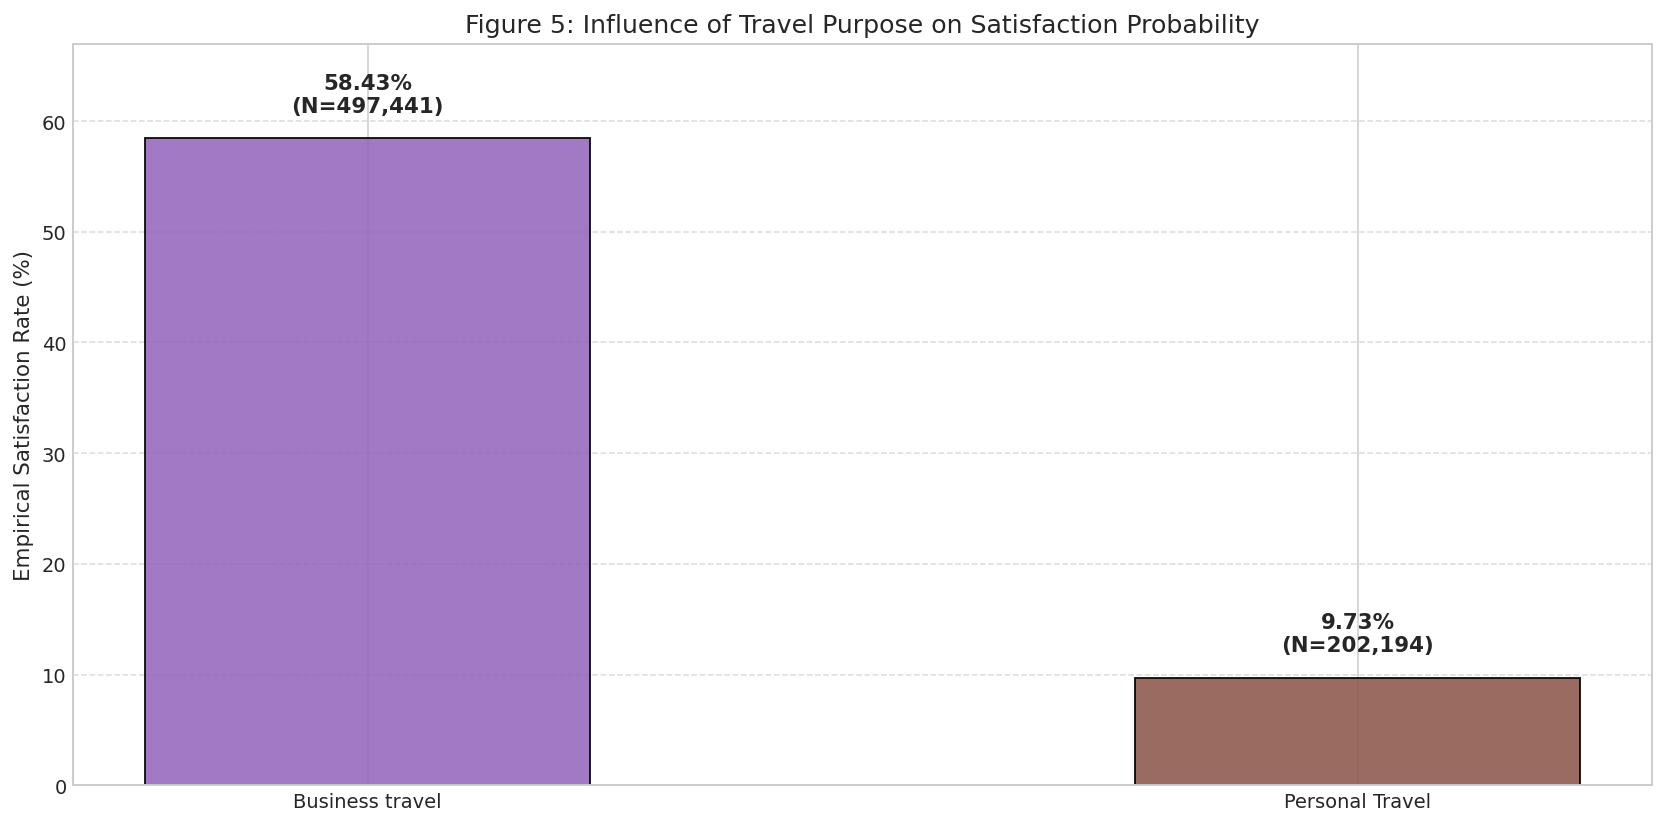

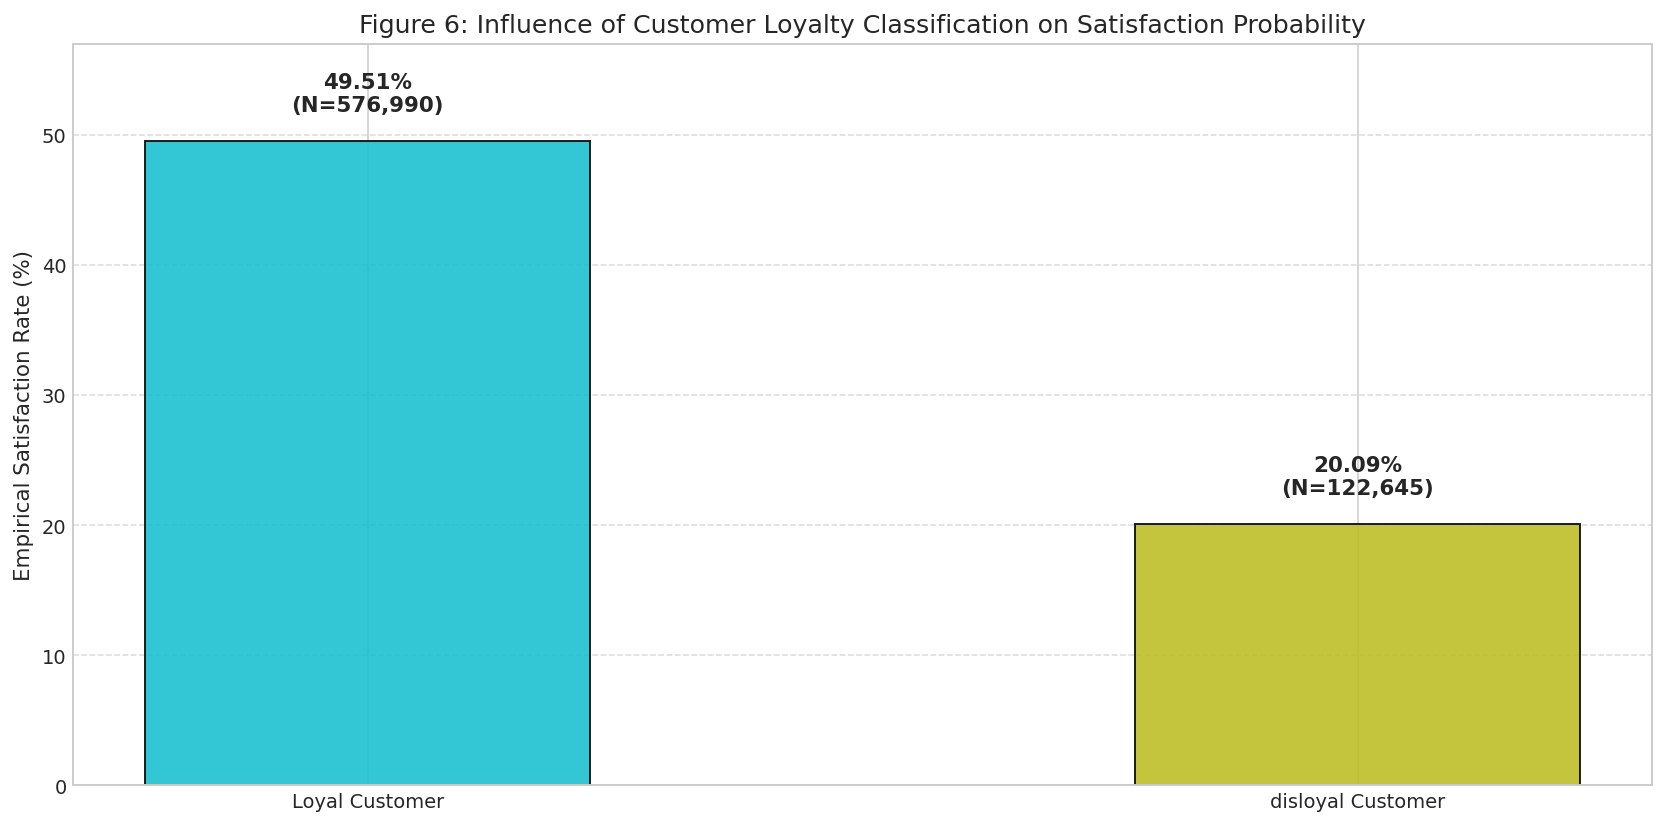

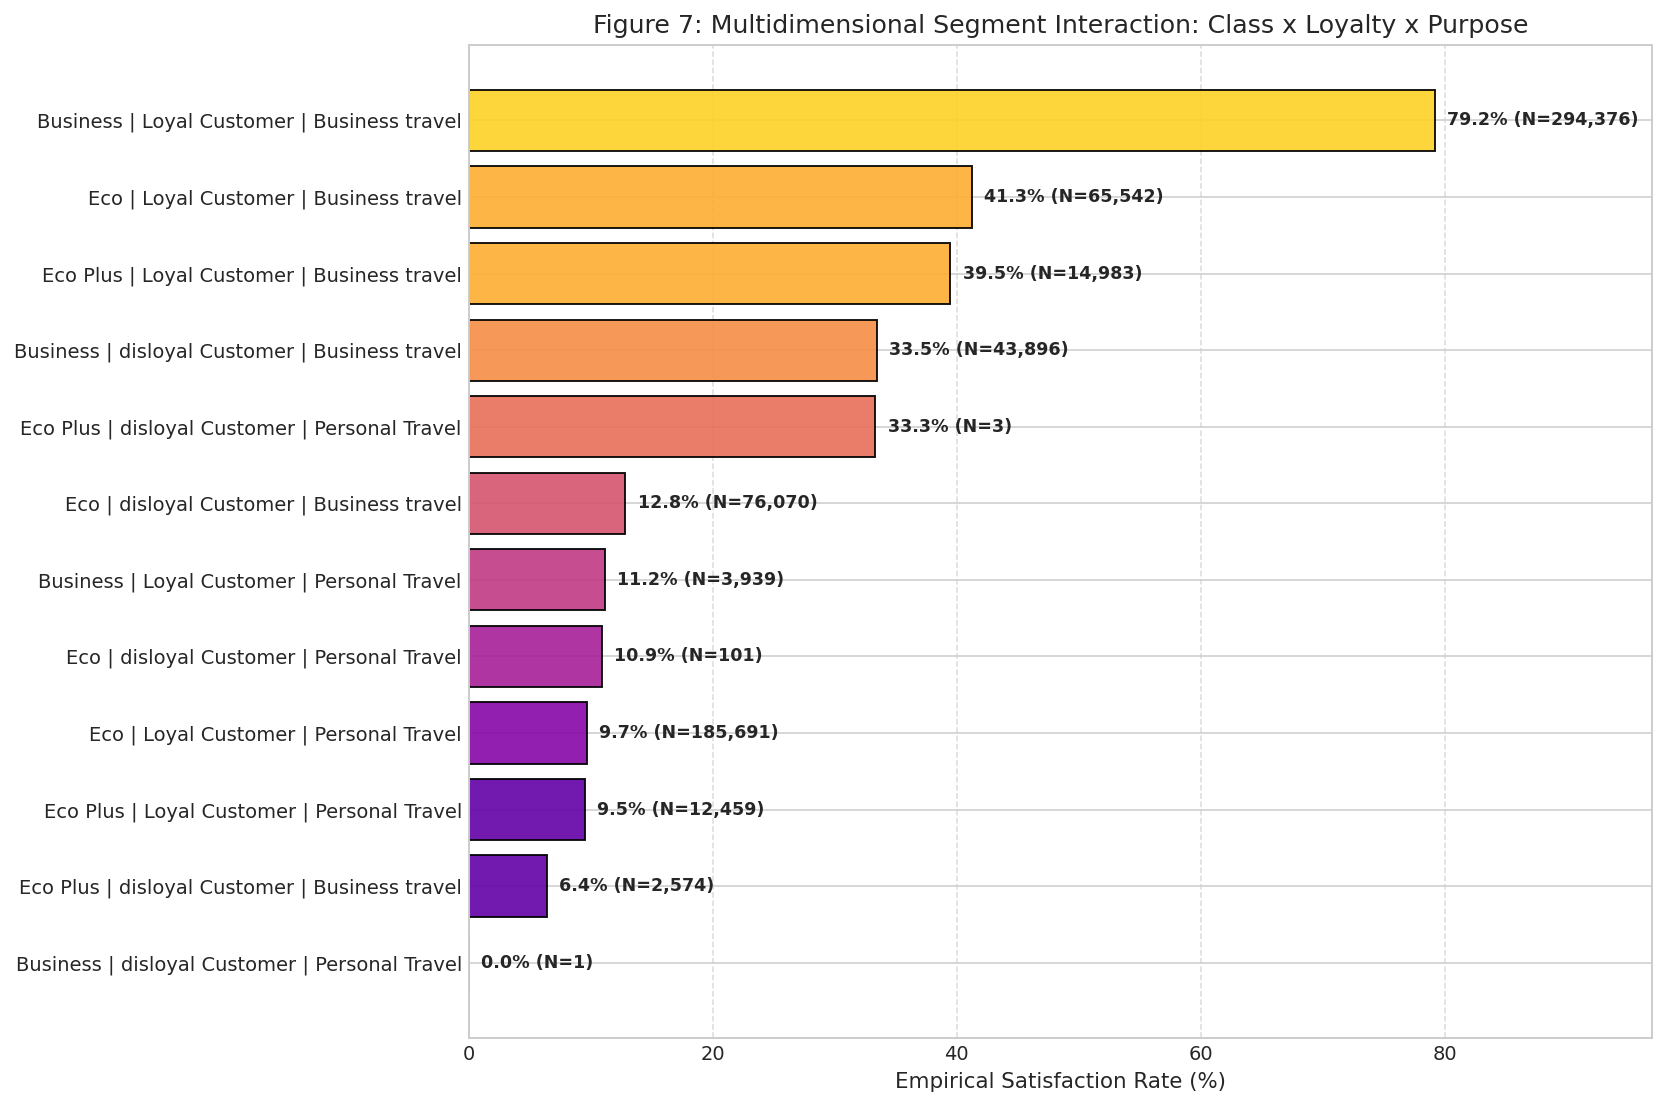

In [6]:
# Plot 4: Travel Class vs Satisfaction Rate
fig, ax = plt.subplots(figsize=(12, 6))
class_summary = train_df.groupby('Class')['target'].agg(['count', 'mean']).reindex(['Business', 'Eco Plus', 'Eco'])
bars = ax.bar(class_summary.index, class_summary['mean'] * 100, color=['#2ca02c', '#ff7f0e', '#1f77b4'], edgecolor='black', width=0.48, alpha=0.88)
ax.set_ylabel('Empirical Satisfaction Rate (%)')
ax.set_title('Figure 4: Passenger Satisfaction Probability Across Cabin Service Classes')
ax.set_ylim(0, 82)
for bar, (idx, row) in zip(bars, class_summary.iterrows()):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, h + 2, f"{h:.2f}%\n(N={int(row['count']):,})",
            ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot 5: Type of Travel vs Satisfaction Rate
fig, ax = plt.subplots(figsize=(12, 6))
travel_summary = train_df.groupby('Type of Travel')['target'].agg(['count', 'mean'])
bars = ax.bar(travel_summary.index, travel_summary['mean'] * 100, color=['#9467bd', '#8c564b'], edgecolor='black', width=0.45, alpha=0.88)
ax.set_ylabel('Empirical Satisfaction Rate (%)')
ax.set_title('Figure 5: Influence of Travel Purpose on Satisfaction Probability')
ax.set_ylim(0, 67)
for bar, (idx, row) in zip(bars, travel_summary.iterrows()):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, h + 2, f"{h:.2f}%\n(N={int(row['count']):,})",
            ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot 6: Customer Type vs Satisfaction Rate
fig, ax = plt.subplots(figsize=(12, 6))
cust_summary = train_df.groupby('Customer Type')['target'].agg(['count', 'mean'])
bars = ax.bar(cust_summary.index, cust_summary['mean'] * 100, color=['#17becf', '#bcbd22'], edgecolor='black', width=0.45, alpha=0.88)
ax.set_ylabel('Empirical Satisfaction Rate (%)')
ax.set_title('Figure 6: Influence of Customer Loyalty Classification on Satisfaction Probability')
ax.set_ylim(0, 57)
for bar, (idx, row) in zip(bars, cust_summary.iterrows()):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, h + 2, f"{h:.2f}%\n(N={int(row['count']):,})",
            ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot 7: High-Order Segment Interaction (Class x Travel Type x Loyalty)
fig, ax = plt.subplots(figsize=(12, 8))
tri_summary = train_df.groupby(['Class', 'Customer Type', 'Type of Travel'])['target'].agg(['count', 'mean']).reset_index()
tri_summary['Segment_Label'] = tri_summary['Class'] + ' | ' + tri_summary['Customer Type'] + ' | ' + tri_summary['Type of Travel']
tri_summary = tri_summary.sort_values(by='mean', ascending=True)

color_scale = plt.cm.get_cmap('plasma', len(tri_summary))
bars = ax.barh(tri_summary['Segment_Label'], tri_summary['mean'] * 100,
               color=color_scale(np.linspace(0.1, 0.9, len(tri_summary))), edgecolor='black', alpha=0.9)
ax.set_xlabel('Empirical Satisfaction Rate (%)')
ax.set_title('Figure 7: Multidimensional Segment Interaction: Class x Loyalty x Purpose')
ax.set_xlim(0, 97)
for bar, (idx, row) in zip(bars, tri_summary.iterrows()):
    w = bar.get_width()
    ax.text(w + 1, bar.get_y() + bar.get_height()/2.0, f"{w:.1f}% (N={int(row['count']):,})",
            ha='left', va='center', fontsize=9, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


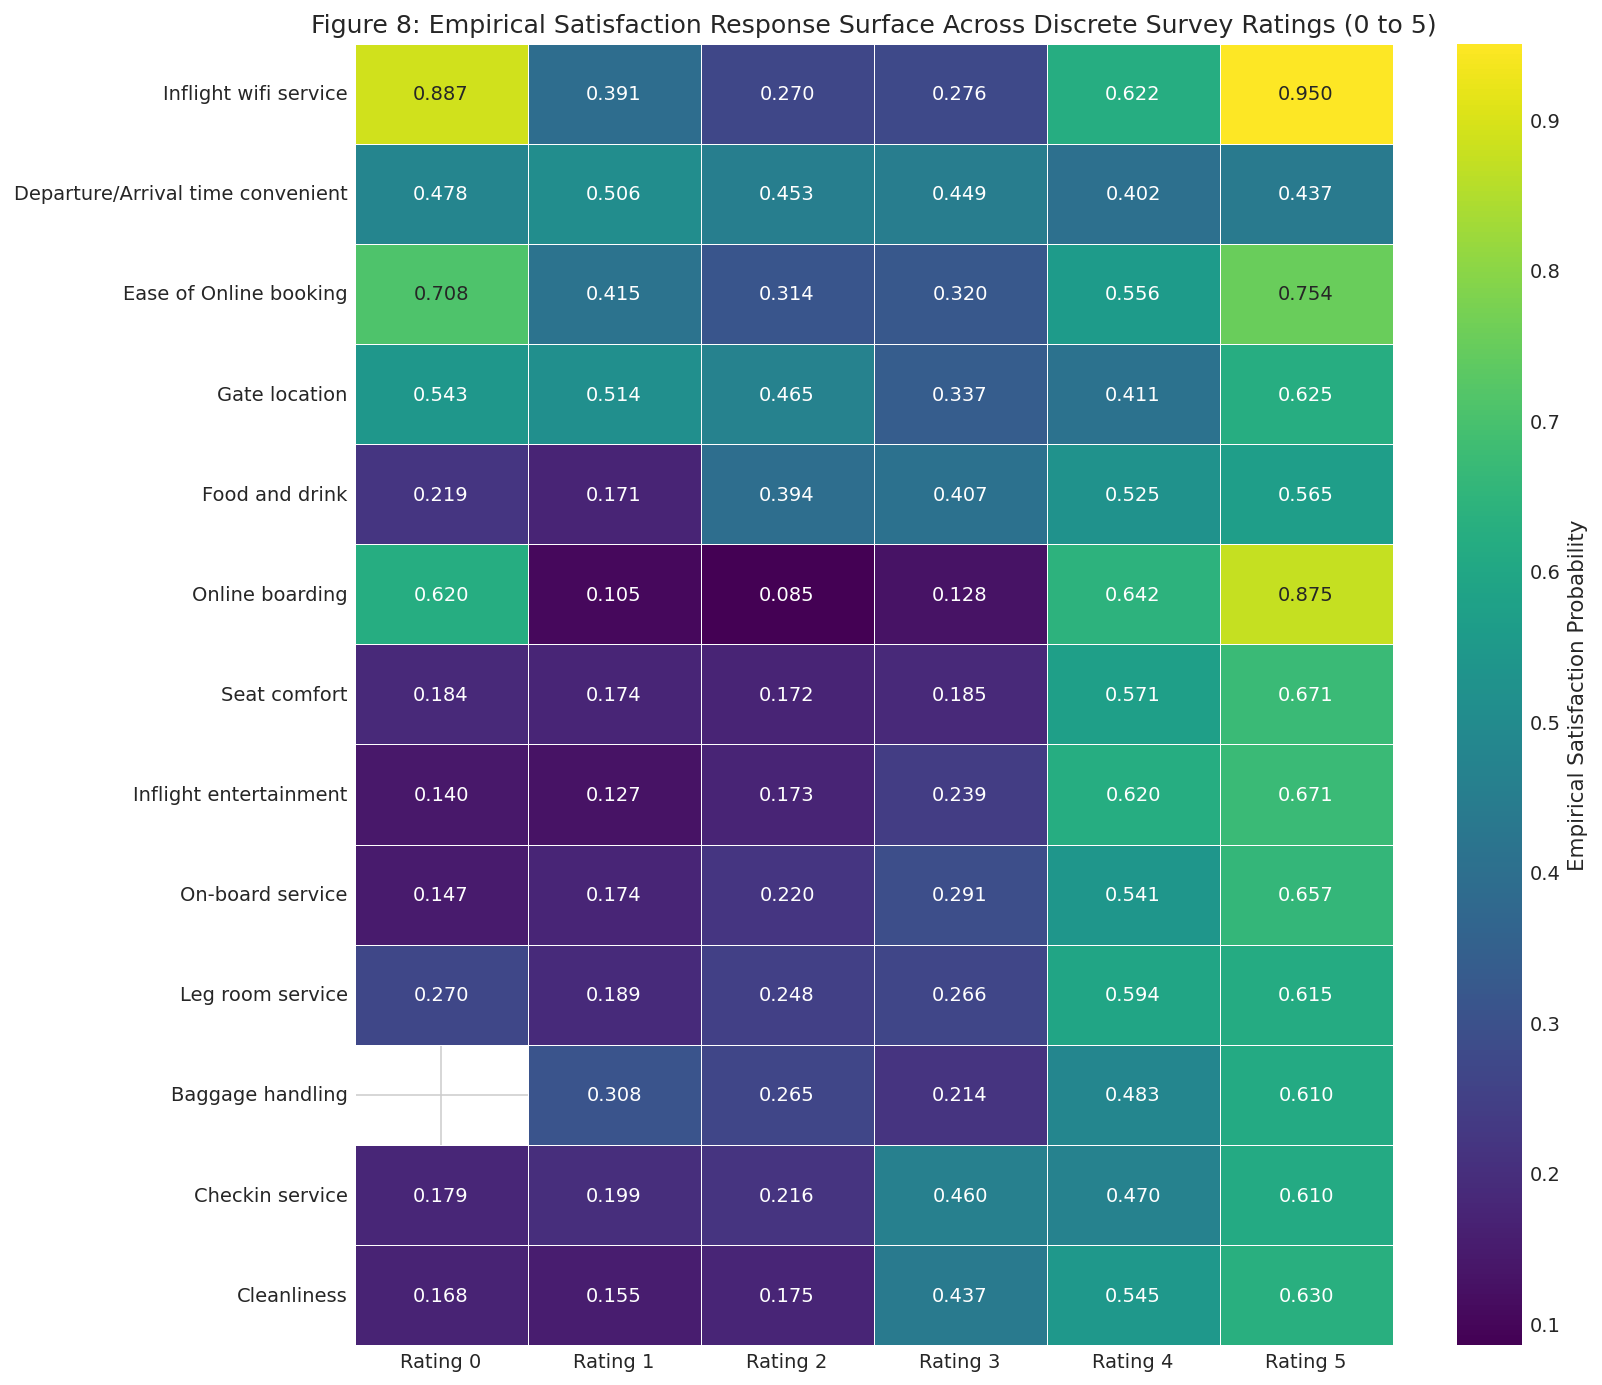

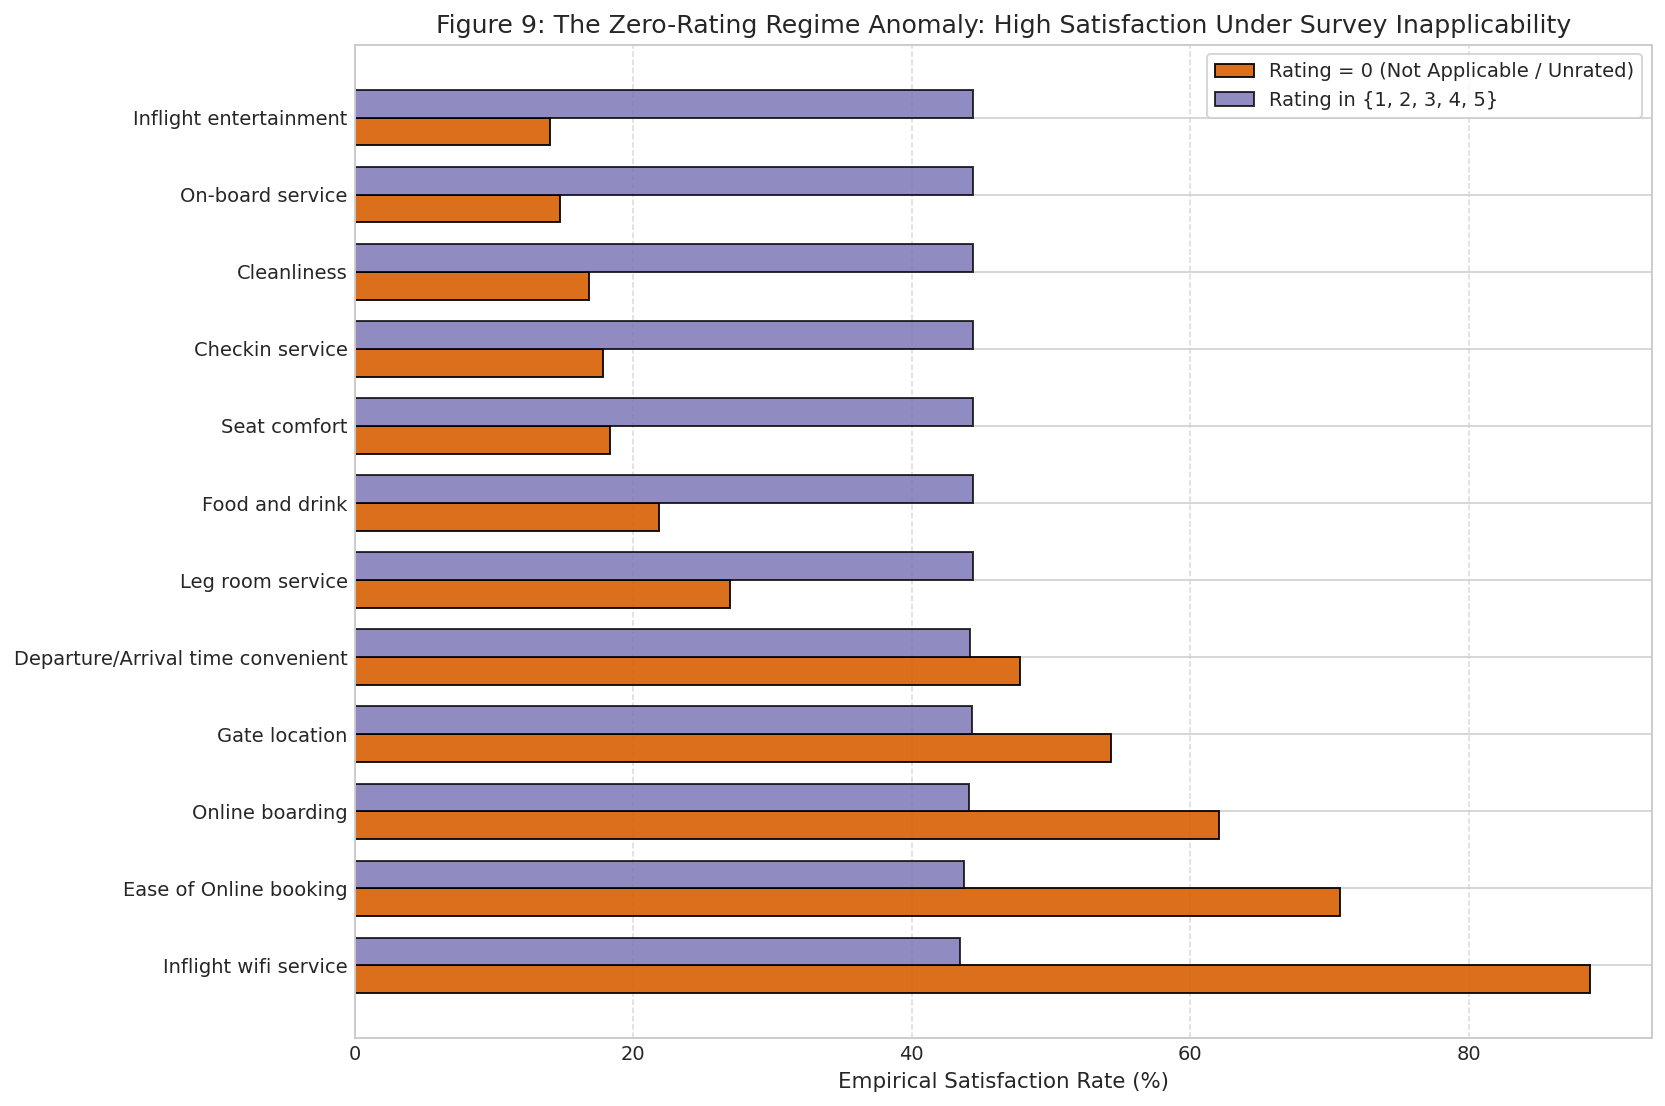

In [7]:
rating_cols = [
    'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking',
    'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment',
    'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness'
]

# Calculate conditional response matrix
response_matrix = np.zeros((len(rating_cols), 6))
for i, col in enumerate(rating_cols):
    score_means = train_df.groupby(col)['target'].mean()
    for s in range(6):
        response_matrix[i, s] = score_means.get(s, np.nan)

# Plot 8: Response Surface Heatmap Across Rating Levels
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(response_matrix, annot=True, fmt='.3f', cmap='viridis', cbar_kws={'label': 'Empirical Satisfaction Probability'},
            xticklabels=[f'Rating {i}' for i in range(6)], yticklabels=rating_cols, ax=ax, linewidths=0.5, linecolor='white')
ax.set_title('Figure 8: Empirical Satisfaction Response Surface Across Discrete Survey Ratings (0 to 5)')
plt.tight_layout()
plt.show()

# Plot 9: The Zero-Rating Regime Anomaly
zero_audit = []
for col in rating_cols:
    cnt_zero = (train_df[col] == 0).sum()
    if cnt_zero > 0:
        p_zero = train_df[train_df[col] == 0]['target'].mean()
        p_active = train_df[train_df[col] > 0]['target'].mean()
        zero_audit.append({'Feature': col, 'Zero_Rate': p_zero, 'Active_Rate': p_active, 'Count': cnt_zero})

zero_df = pd.DataFrame(zero_audit).sort_values(by='Zero_Rate', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
y_indices = np.arange(len(zero_df))
width_b = 0.36
ax.barh(y_indices - width_b/2, zero_df['Zero_Rate'] * 100, width_b, label='Rating = 0 (Not Applicable / Unrated)', color='#d95f02', edgecolor='black', alpha=0.9)
ax.barh(y_indices + width_b/2, zero_df['Active_Rate'] * 100, width_b, label='Rating in {1, 2, 3, 4, 5}', color='#7570b3', edgecolor='black', alpha=0.8)
ax.set_yticks(y_indices)
ax.set_yticklabels(zero_df['Feature'])
ax.set_xlabel('Empirical Satisfaction Rate (%)')
ax.set_title('Figure 9: The Zero-Rating Regime Anomaly: High Satisfaction Under Survey Inapplicability')
ax.legend(frameon=True)
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


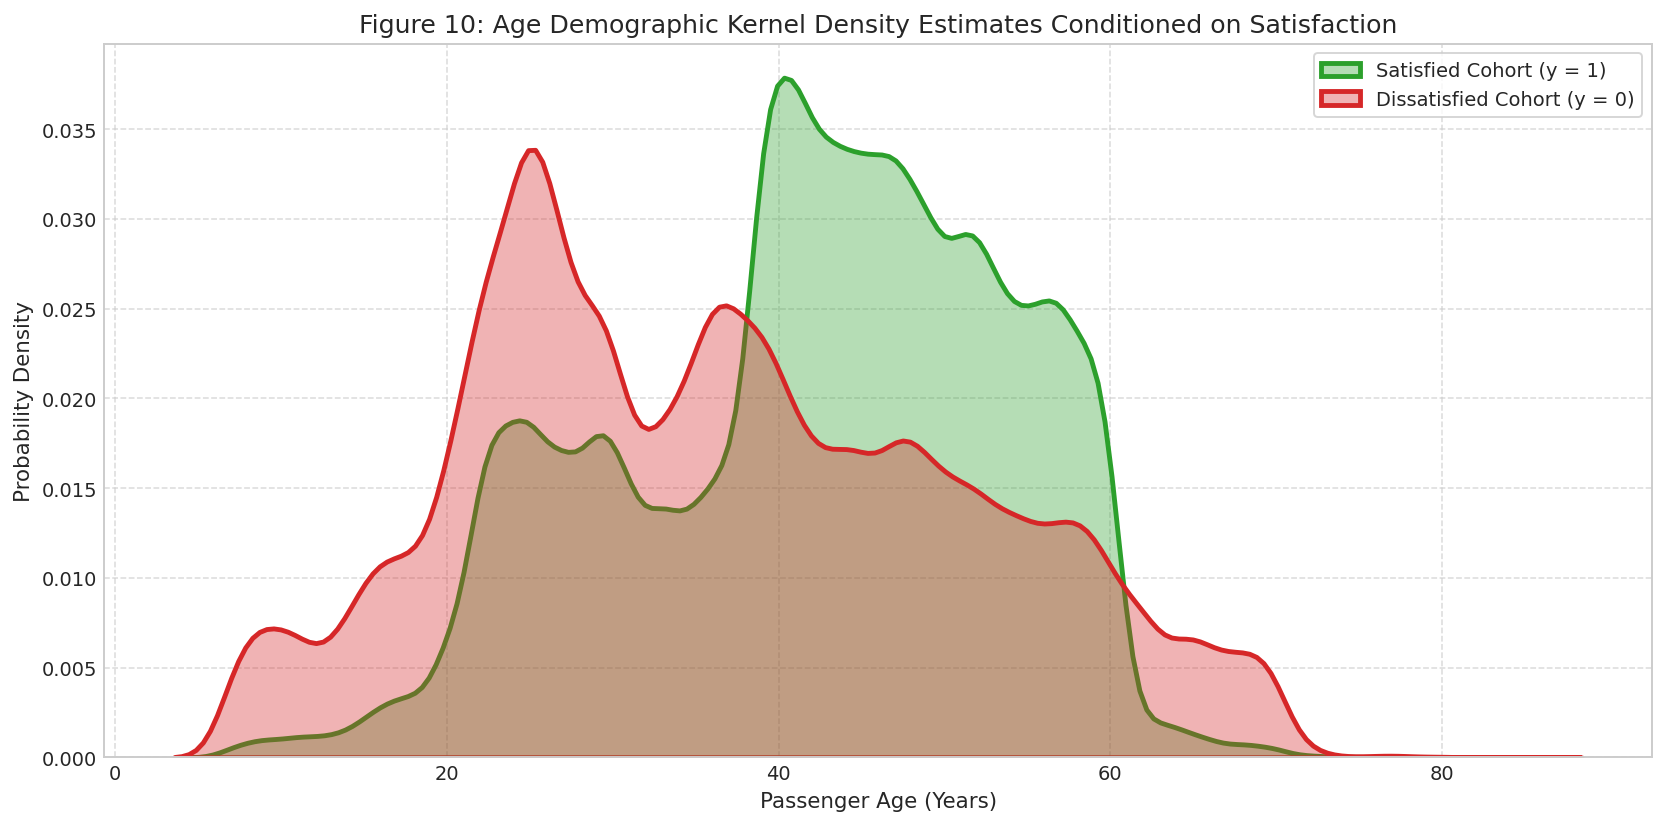

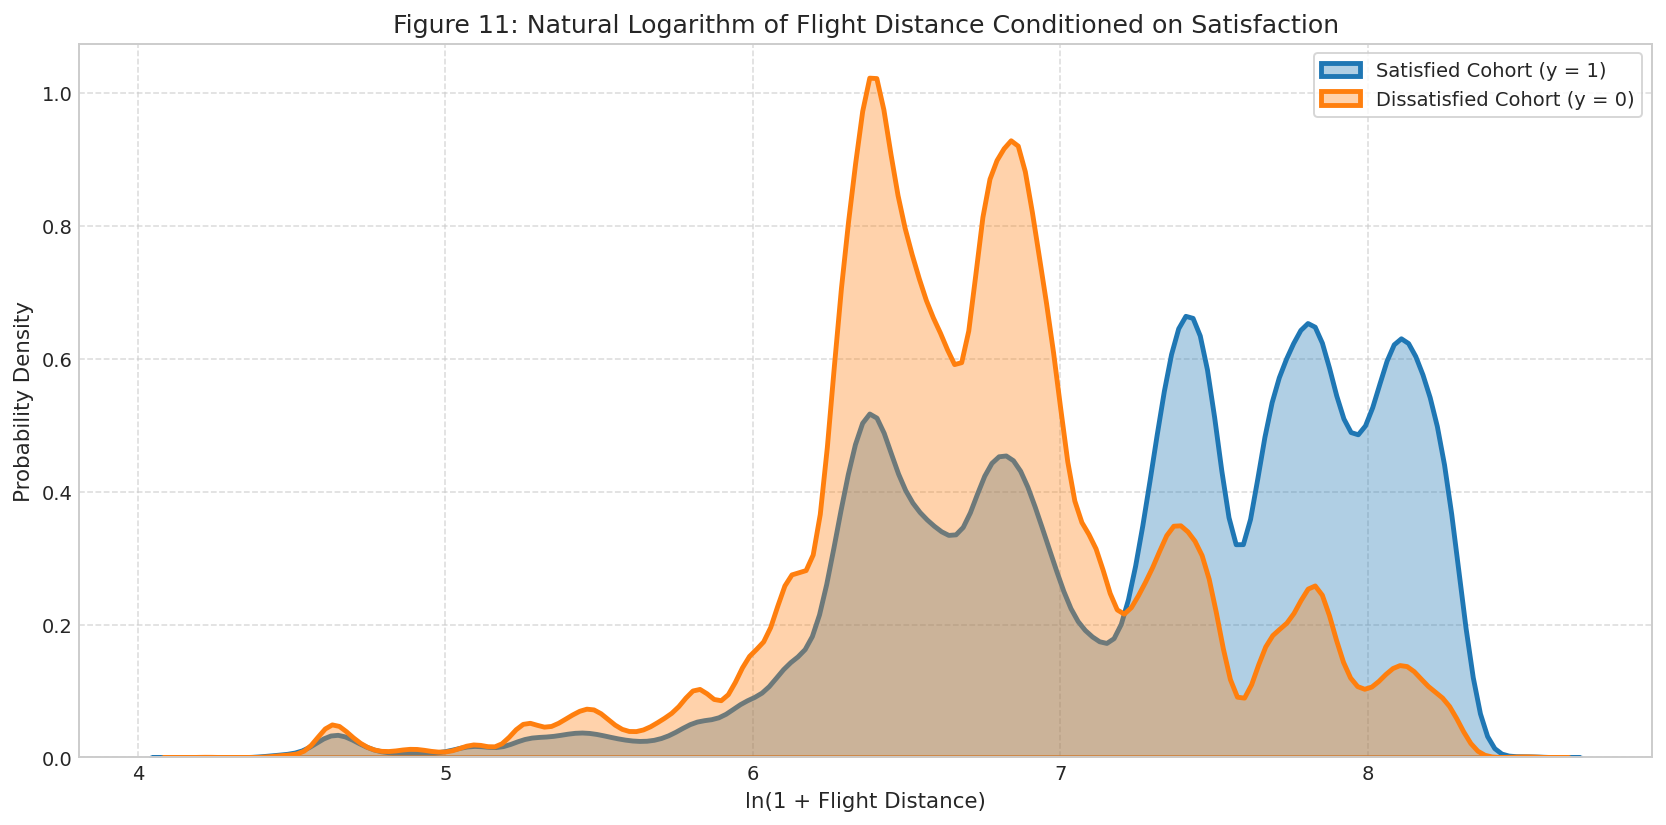

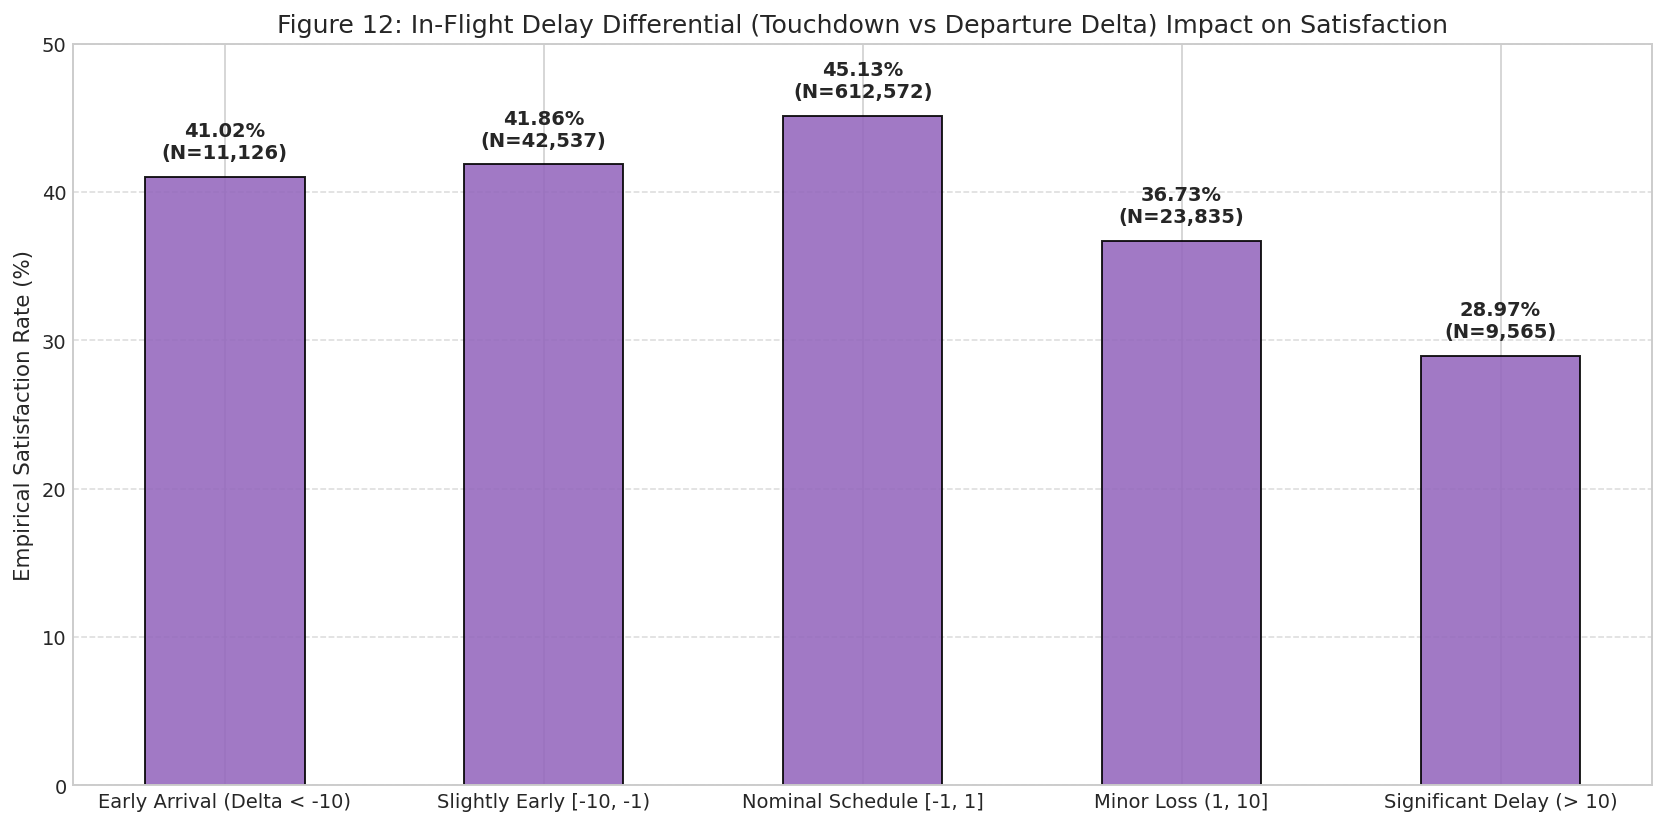

In [8]:
# Plot 10: Age Demographic Density Estimates
fig, ax = plt.subplots(figsize=(12, 6))
sns.kdeplot(train_df[train_df['target'] == 1]['Age'], label='Satisfied Cohort (y = 1)', color='#2ca02c', fill=True, alpha=0.35, linewidth=2.5, ax=ax)
sns.kdeplot(train_df[train_df['target'] == 0]['Age'], label='Dissatisfied Cohort (y = 0)', color='#d62728', fill=True, alpha=0.35, linewidth=2.5, ax=ax)
ax.set_title('Figure 10: Age Demographic Kernel Density Estimates Conditioned on Satisfaction')
ax.set_xlabel('Passenger Age (Years)')
ax.set_ylabel('Probability Density')
ax.legend(frameon=True)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot 11: Flight Distance Distribution
fig, ax = plt.subplots(figsize=(12, 6))
sns.kdeplot(np.log1p(train_df[train_df['target'] == 1]['Flight Distance']), label='Satisfied Cohort (y = 1)', color='#1f77b4', fill=True, alpha=0.35, linewidth=2.5, ax=ax)
sns.kdeplot(np.log1p(train_df[train_df['target'] == 0]['Flight Distance']), label='Dissatisfied Cohort (y = 0)', color='#ff7f0e', fill=True, alpha=0.35, linewidth=2.5, ax=ax)
ax.set_title('Figure 11: Natural Logarithm of Flight Distance Conditioned on Satisfaction')
ax.set_xlabel('ln(1 + Flight Distance)')
ax.set_ylabel('Probability Density')
ax.legend(frameon=True)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot 12: In-Flight Delay Differential vs Satisfaction
train_df['Delay_Delta_Exp'] = train_df['Arrival Delay in Minutes'] - train_df['Departure Delay in Minutes']
delay_bins = pd.cut(train_df['Delay_Delta_Exp'], bins=[-100, -10, -1, 1, 10, 100],
                    labels=['Early Arrival (Delta < -10)', 'Slightly Early [-10, -1)', 'Nominal Schedule [-1, 1]', 'Minor Loss (1, 10]', 'Significant Delay (> 10)'])
delta_summary = train_df.groupby(delay_bins)['target'].agg(['count', 'mean'])

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(delta_summary.index.astype(str), delta_summary['mean'] * 100, color='#9467bd', edgecolor='black', width=0.5, alpha=0.88)
ax.set_ylabel('Empirical Satisfaction Rate (%)')
ax.set_title('Figure 12: In-Flight Delay Differential (Touchdown vs Departure Delta) Impact on Satisfaction')
ax.set_ylim(0, 50)
for bar, (idx, row) in zip(bars, delta_summary.iterrows()):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, h + 1, f"{h:.2f}%\n(N={int(row['count']):,})",
            ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


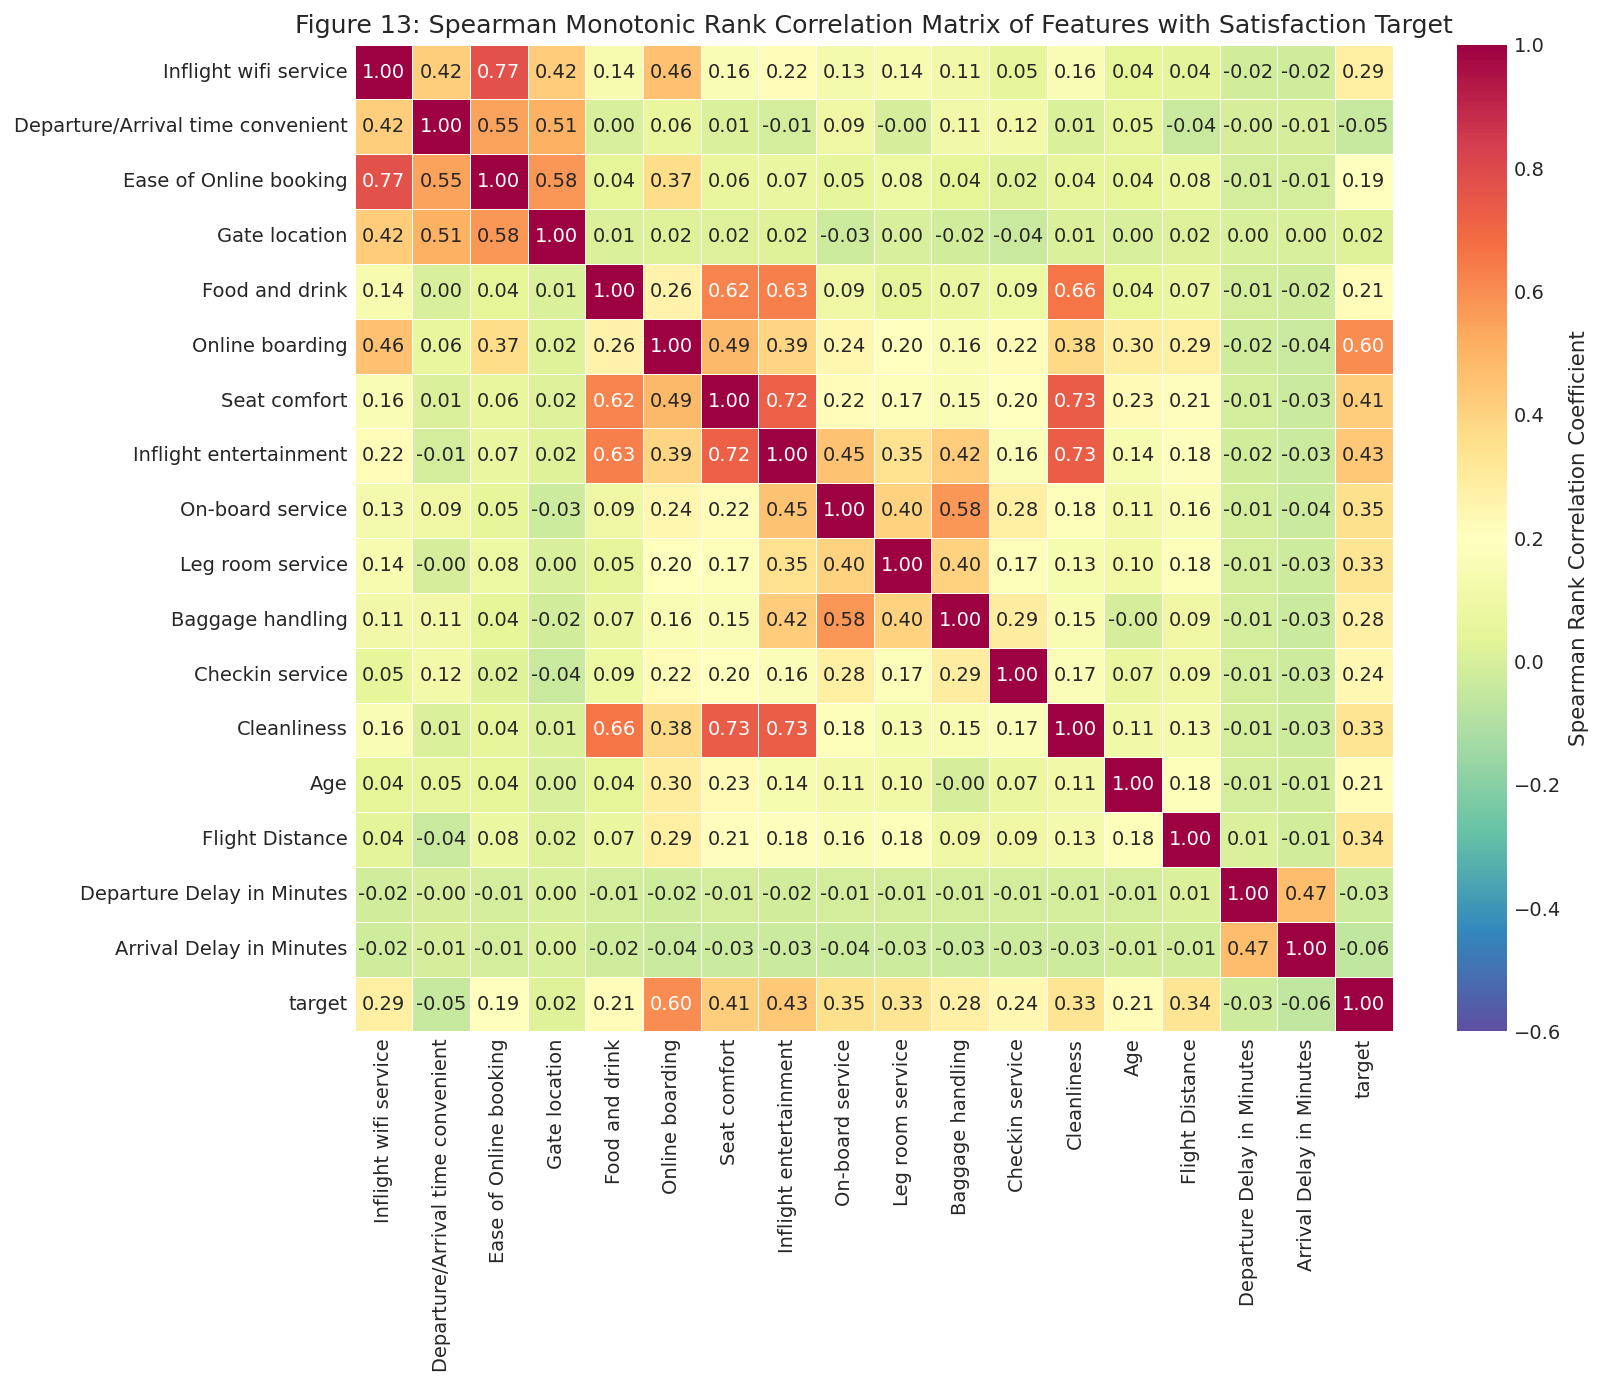

In [9]:
features_for_spearman = rating_cols + ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'target']
spearman_matrix = train_df[features_for_spearman].corr(method='spearman')

# Plot 13: Spearman Monotonic Rank Correlation Matrix (Placed Top-to-Bottom)
fig, ax = plt.subplots(figsize=(12, 10))
corr_mask = np.triu(np.ones_like(spearman_matrix, dtype=bool))
sns.heatmap(spearman_matrix, cmap='Spectral_r', annot=True, fmt='.2f', vmin=-0.6, vmax=1.0,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Spearman Rank Correlation Coefficient'}, ax=ax)
ax.set_title('Figure 13: Spearman Monotonic Rank Correlation Matrix of Features with Satisfaction Target')
plt.tight_layout()
plt.show()


# 5. Theoretical Feature Engineering & Representation Learning

To maximize the discriminatory capacity of our downstream learners, we construct domain-informed mathematical representations:

## 5.1 Psychometric Latent Domain Indices
In psychometrics, survey batteries reflect underlying latent constructs. We define orthogonal factor proxies:
- **Physical Comfort**: $\text{Index}_{\text{comfort}} = \frac{1}{3}(\text{Seat comfort} + \text{Leg room service} + \text{Cleanliness})$
- **Crew & Service Delivery**: $\text{Index}_{\text{service}} = \frac{1}{3}(\text{On-board service} + \text{Baggage handling} + \text{Checkin service})$
- **Digital Touchpoint Efficiency**: $\text{Index}_{\text{digital}} = \frac{1}{3}(\text{Inflight wifi} + \text{Ease of Online booking} + \text{Online boarding})$
- **In-Flight Hospitality**: $\text{Index}_{\text{amenities}} = \frac{1}{2}(\text{Inflight entertainment} + \text{Food and drink})$
- **Airport Ground Logistics**: $\text{Index}_{\text{airport}} = \frac{1}{2}(\text{Departure/Arrival time convenient} + \text{Gate location})$

## 5.2 Survey Statistical Moments
- $\text{Rating}_{\text{sum}} = \sum_{j=1}^{13} r_j$
- $\text{Rating}_{\text{mean}} = \frac{1}{13} \sum_{j=1}^{13} r_j$
- $\text{Rating}_{\text{std}} = \sqrt{\frac{1}{12}\sum_{j=1}^{13} (r_j - \bar{r})^2}$ (capturing passenger score polarization)
- $\text{Rating}_{\text{range}} = \max_j r_j - \min_j r_j$
- Friction & Delight Quantifiers: $\text{Count}_{\text{zero}} = \sum \mathbb{I}(r_j = 0)$, $\text{Count}_{\text{dissatisfied}} = \sum \mathbb{I}(r_j \le 2)$, $\text{Count}_{\text{delighted}} = \sum \mathbb{I}(r_j \ge 4)$
- Net Delight Score: $\text{Count}_{\text{delighted}} - \text{Count}_{\text{dissatisfied}}$

## 5.3 Flight Kinematics & Delay Impact Ratios
Commercial aircraft operate at an average ground speed of $v \approx 500\text{ mph}$. We formulate the estimated en-route airborne flight duration:

$$T_{\text{air}} = \frac{\text{Flight Distance}}{500} \times 60 \text{ minutes}$$

The delay impact relative to flight duration is defined as:

$$\text{Delay Ratio} = \frac{\text{Total Delay}}{T_{\text{air}} + 1.0}$$

## 5.4 Manifold Projections & Centroid Distances
We execute Principal Component Analysis (PCA) on the survey rating matrix $\mathbf{R} \in \mathbb{R}^{N \times 13}$ to capture the leading orthogonal variance directions ($PC_1, PC_2, PC_3$). Additionally, we compute Euclidean distances to the canonical Satisfied and Dissatisfied rating archetypes in $\mathbb{R}^{13}$ space:

$$d^+(\mathbf{x}) = \|\mathbf{x} - \boldsymbol{\mu}_+\|_2, \quad d^-(\mathbf{x}) = \|\mathbf{x} - \boldsymbol{\mu}_-\|_2, \quad \text{Archetype Proximity} = \frac{d^-(\mathbf{x})}{d^+(\mathbf{x}) + d^-(\mathbf{x}) + \epsilon}$$

In [10]:
def engineer_representations(df_raw, pca_model=None, is_train=True):
    df = df_raw.copy()
    
    # 1. Operational Delay Dynamics & Kinematics
    df['Total_Delay'] = df['Departure Delay in Minutes'] + df['Arrival Delay in Minutes']
    df['Delay_Delta'] = df['Arrival Delay in Minutes'] - df['Departure Delay in Minutes']
    df['Is_Delayed'] = ((df['Departure Delay in Minutes'] > 0) | (df['Arrival Delay in Minutes'] > 0)).astype(np.int8)
    df['Severe_Delay'] = ((df['Departure Delay in Minutes'] >= 60) | (df['Arrival Delay in Minutes'] >= 60)).astype(np.int8)
    df['Delay_Per_Distance'] = df['Total_Delay'] / (df['Flight Distance'] + 1.0)
    
    # Kinematic airborne time proxy (nominal ground speed ~ 500 mph)
    df['Flight_Hours_Proxy'] = df['Flight Distance'] / 500.0
    df['Flight_Minutes_Proxy'] = df['Flight_Hours_Proxy'] * 60.0
    df['Delay_To_Flight_Ratio'] = df['Total_Delay'] / (df['Flight_Minutes_Proxy'] + 1.0)
    
    # Non-linear representations
    df['Log_Flight_Distance'] = np.log1p(df['Flight Distance'])
    df['Log_Departure_Delay'] = np.log1p(df['Departure Delay in Minutes'])
    df['Log_Arrival_Delay'] = np.log1p(df['Arrival Delay in Minutes'])
    df['Log_Total_Delay'] = np.log1p(df['Total_Delay'])
    
    # 2. Survey Statistical Moment Aggregations
    df['Rating_Sum'] = df[rating_cols].sum(axis=1)
    df['Rating_Mean'] = df[rating_cols].mean(axis=1)
    df['Rating_Std'] = df[rating_cols].std(axis=1)
    df['Rating_Min'] = df[rating_cols].min(axis=1)
    df['Rating_Max'] = df[rating_cols].max(axis=1)
    df['Rating_Range'] = df['Rating_Max'] - df['Rating_Min']
    df['Rating_Zero_Count'] = (df[rating_cols] == 0).sum(axis=1).astype(np.int8)
    df['Rating_Low_Count'] = (df[rating_cols] <= 2).sum(axis=1).astype(np.int8)
    df['Rating_High_Count'] = (df[rating_cols] >= 4).sum(axis=1).astype(np.int8)
    df['Net_Delight_Score'] = df['Rating_High_Count'] - df['Rating_Low_Count']
    
    # 3. Psychometric Latent Domain Indices
    df['Index_Comfort'] = df[['Seat comfort', 'Leg room service', 'Cleanliness']].mean(axis=1)
    df['Index_Staff_Service'] = df[['On-board service', 'Baggage handling', 'Checkin service']].mean(axis=1)
    df['Index_Digital'] = df[['Inflight wifi service', 'Ease of Online booking', 'Online boarding']].mean(axis=1)
    df['Index_Amenities'] = df[['Inflight entertainment', 'Food and drink']].mean(axis=1)
    df['Index_Airport_Logistics'] = df[['Departure/Arrival time convenient', 'Gate location']].mean(axis=1)
    
    # 4. Multi-Way Categorical Context Combinations
    df['Class_x_TravelType'] = df['Class'].astype(str) + '_' + df['Type of Travel'].astype(str)
    df['CustomerType_x_TravelType'] = df['Customer Type'].astype(str) + '_' + df['Type of Travel'].astype(str)
    df['CustomerType_x_Class'] = df['Customer Type'].astype(str) + '_' + df['Class'].astype(str)
    df['Tri_Interaction'] = df['Class'].astype(str) + '_' + df['Customer Type'].astype(str) + '_' + df['Type of Travel'].astype(str)
    df['Wifi_x_Boarding'] = df['Inflight wifi service'].astype(str) + '_' + df['Online boarding'].astype(str)
    
    # 5. Principal Component Analysis (Spectral Decomposition)
    if is_train:
        pca = PCA(n_components=3, random_state=RANDOM_SEED)
        pca_transformed = pca.fit_transform(df[rating_cols])
    else:
        pca = pca_model
        pca_transformed = pca.transform(df[rating_cols])
        
    df['PCA_Rating_1'] = pca_transformed[:, 0]
    df['PCA_Rating_2'] = pca_transformed[:, 1]
    df['PCA_Rating_3'] = pca_transformed[:, 2]
    
    # 6. Archetype Centroid Proximity Metrics
    mu_pos = np.array([4.5, 4.0, 4.5, 3.5, 4.0, 4.8, 4.5, 4.6, 4.5, 4.5, 4.5, 4.2, 4.5])
    mu_neg = np.array([1.5, 2.5, 1.8, 3.0, 1.8, 1.8, 2.0, 2.0, 2.2, 2.0, 2.5, 2.5, 2.0])
    
    rating_vals = df[rating_cols].values
    dist_pos = np.linalg.norm(rating_vals - mu_pos, axis=1)
    dist_neg = np.linalg.norm(rating_vals - mu_neg, axis=1)
    
    df['Dist_To_Satisfied_Archetype'] = dist_pos
    df['Dist_To_Dissatisfied_Archetype'] = dist_neg
    df['Archetype_Proximity_Ratio'] = dist_neg / (dist_pos + dist_neg + 1e-6)
    
    return df, pca

print("Executing automated feature engineering pipeline...")
t0 = time.time()
train_engineered, fitted_pca = engineer_representations(train_df, is_train=True)
test_engineered, _ = engineer_representations(test_df, pca_model=fitted_pca, is_train=False)

print(f"Feature transformation completed in {time.time() - t0:.2f} seconds.")
print(f"Constructed Training Feature Matrix: {train_engineered.shape[0]:,} rows x {train_engineered.shape[1]} columns")
print(f"Constructed Testing Feature Matrix:  {test_engineered.shape[0]:,} rows x {test_engineered.shape[1]} columns")


Executing automated feature engineering pipeline...
Feature transformation completed in 3.37 seconds.
Constructed Training Feature Matrix: 699,635 rows x 64 columns
Constructed Testing Feature Matrix:  299,844 rows x 61 columns


# 6. Validation Protocol: Stratified K-Fold with In-Fold Bayesian Target Encoding

To prevent data leakage, categorical target encodings must be strictly fit within each cross-validation training fold:

$$\hat{S}_c^{(k)} = \frac{n_c^{(k)} \cdot \bar{y}_c^{(k)} + m \cdot \bar{y}_{\text{global}}^{(k)}}{n_c^{(k)} + m}$$

where $n_c^{(k)}$ is the frequency of category $c$ in the training partition of fold $k$, $\bar{y}_c^{(k)}$ is the partition-specific mean target value, $\bar{y}_{\text{global}}^{(k)}$ is the global training mean, and $m=10.0$ represents the empirical Bayesian smoothing prior weight.

In [11]:
categorical_features = [
    'Gender', 'Customer Type', 'Type of Travel', 'Class',
    'Class_x_TravelType', 'CustomerType_x_TravelType', 'CustomerType_x_Class',
    'Tri_Interaction', 'Wifi_x_Boarding'
]

# Frequency Encoding over the joint observation space
for col in categorical_features:
    freq_map = pd.concat([train_engineered[col], test_engineered[col]], axis=0).value_counts(normalize=True).to_dict()
    train_engineered[f'{col}_Freq'] = train_engineered[col].map(freq_map).astype(np.float32)
    test_engineered[f'{col}_Freq'] = test_engineered[col].map(freq_map).astype(np.float32)

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)

smoothing_weight = 10.0
global_target_mean = train_engineered['target'].mean()

for col in categorical_features:
    train_engineered[f'{col}_TE'] = np.nan
    test_engineered[f'{col}_TE'] = 0.0

for fold, (train_idx, val_idx) in enumerate(skf.split(train_engineered, train_engineered['target'])):
    tr_subset = train_engineered.iloc[train_idx]
    val_subset = train_engineered.iloc[val_idx]
    
    for col in categorical_features:
        counts = tr_subset.groupby(col)['target'].count()
        means = tr_subset.groupby(col)['target'].mean()
        te_smoothed = (counts * means + smoothing_weight * global_target_mean) / (counts + smoothing_weight)
        
        train_engineered.loc[val_idx, f'{col}_TE'] = val_subset[col].map(te_smoothed).fillna(global_target_mean)
        test_engineered[f'{col}_TE'] += test_engineered[col].map(te_smoothed).fillna(global_target_mean) / N_SPLITS

# Ensure categorical dtype for native GBDT handling
for col in categorical_features:
    train_engineered[col] = train_engineered[col].astype('category')
    test_engineered[col] = test_engineered[col].astype('category')

excluded_cols = ['id', 'satisfaction', 'target', 'Delay_Delta_Exp']
model_features = [c for c in train_engineered.columns if c not in excluded_cols]

print(f"Total Predictive Dimension Space: {len(model_features)} features")
print(f"Features: {model_features}")


Total Predictive Dimension Space: 78 features
Features: ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Gender', 'Customer Type', 'Type of Travel', 'Class', 'Arrival_Delay_is_missing', 'Total_Delay', 'Delay_Delta', 'Is_Delayed', 'Severe_Delay', 'Delay_Per_Distance', 'Flight_Hours_Proxy', 'Flight_Minutes_Proxy', 'Delay_To_Flight_Ratio', 'Log_Flight_Distance', 'Log_Departure_Delay', 'Log_Arrival_Delay', 'Log_Total_Delay', 'Rating_Sum', 'Rating_Mean', 'Rating_Std', 'Rating_Min', 'Rating_Max', 'Rating_Range', 'Rating_Zero_Count', 'Rating_Low_Count', 'Rating_High_Count', 'Net_Delight_Score', 'Index_Comfort', 'Index_Staff_Service', 'Index_Digital', 'Index_Amenities', 'Index_Airport

# 7. Multi-Model Architecture Suite

## 7.1 Model 1: High-Performance Multi-Threaded LightGBM Classifier
LightGBM implements leaf-wise tree growth with Gradient-based One-Side Sampling (GOSS) and Exclusive Feature Bundling (EFB). The histogram-based splitting algorithm bins continuous feature values into discrete histograms, accelerating split evaluation and regularizing tree structure across multi-threaded CPU architectures.

In [12]:
lgb_hyperparams = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.035,
    'num_leaves': 63,
    'max_depth': 9,
    'colsample_bytree': 0.75,
    'subsample': 0.80,
    'subsample_freq': 1,
    'min_child_samples': 50,
    'random_state': RANDOM_SEED,
    'verbose': -1,
    'n_estimators': 1800,
    'n_jobs': -1,
    'device': 'cpu'
}

oof_lgb = np.zeros(len(train_engineered))
test_preds_lgb = np.zeros(len(test_engineered))
lgb_feature_importances = np.zeros(len(model_features))

print(f"Initiating 5-Fold Stratified Cross-Validation: LightGBM Classifier...")
for fold, (train_idx, val_idx) in enumerate(skf.split(train_engineered, train_engineered['target'])):
    X_tr, y_tr = train_engineered.iloc[train_idx][model_features], train_engineered.iloc[train_idx]['target']
    X_va, y_va = train_engineered.iloc[val_idx][model_features], train_engineered.iloc[val_idx]['target']
    
    clf_lgb = lgb.LGBMClassifier(**lgb_hyperparams)
    with suppress_c_stderr():
        clf_lgb.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[lgb.early_stopping(stopping_rounds=60, verbose=False), lgb.log_evaluation(period=0)]
        )
        
    val_probs = clf_lgb.predict_proba(X_va)[:, 1]
    oof_lgb[val_idx] = val_probs
    fold_auc = roc_auc_score(y_va, val_probs)
    print(f"  Fold {fold + 1} LightGBM Out-Of-Fold ROC-AUC: {fold_auc:.6f}")
    
    test_preds_lgb += clf_lgb.predict_proba(test_engineered[model_features])[:, 1] / N_SPLITS
    lgb_feature_importances += clf_lgb.feature_importances_ / N_SPLITS

overall_lgb_auc = roc_auc_score(train_engineered['target'], oof_lgb)
print(f"Overall LightGBM Stratified Out-Of-Fold ROC-AUC: {overall_lgb_auc:.6f}")


Initiating 5-Fold Stratified Cross-Validation: LightGBM Classifier...
  Fold 1 LightGBM Out-Of-Fold ROC-AUC: 0.958734
  Fold 2 LightGBM Out-Of-Fold ROC-AUC: 0.957423
  Fold 3 LightGBM Out-Of-Fold ROC-AUC: 0.959327
  Fold 4 LightGBM Out-Of-Fold ROC-AUC: 0.958639
  Fold 5 LightGBM Out-Of-Fold ROC-AUC: 0.958618
Overall LightGBM Stratified Out-Of-Fold ROC-AUC: 0.958543


## 7.2 Model 2: GPU-Accelerated XGBoost Classifier
XGBoost optimizes an exact second-order Taylor expansion of the objective function:

$$\mathcal{L}^{(t)} \approx \sum_{i=1}^N \left[ g_i f_t(\mathbf{x}_i) + \frac{1}{2} h_i f_t^2(\mathbf{x}_i) \right] + \Omega(f_t)$$

where $g_i = \partial_{\hat{y}^{(t-1)}} \ell(y_i, \hat{y}^{(t-1)})$ and $h_i = \partial^2_{\hat{y}^{(t-1)}} \ell(y_i, \hat{y}^{(t-1)})$. The `hist` tree method executes fully on CUDA cores.

In [13]:
xgb_hyperparams = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'tree_method': 'hist',
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'learning_rate': 0.035,
    'max_depth': 7,
    'subsample': 0.80,
    'colsample_bytree': 0.75,
    'min_child_weight': 35,
    'n_estimators': 1800,
    'random_state': RANDOM_SEED,
    'enable_categorical': True
}

oof_xgb = np.zeros(len(train_engineered))
test_preds_xgb = np.zeros(len(test_engineered))
xgb_feature_importances = np.zeros(len(model_features))

print(f"Initiating 5-Fold Stratified Cross-Validation: XGBoost Classifier...")
for fold, (train_idx, val_idx) in enumerate(skf.split(train_engineered, train_engineered['target'])):
    X_tr, y_tr = train_engineered.iloc[train_idx][model_features], train_engineered.iloc[train_idx]['target']
    X_va, y_va = train_engineered.iloc[val_idx][model_features], train_engineered.iloc[val_idx]['target']
    
    clf_xgb = xgb.XGBClassifier(**xgb_hyperparams)
    with suppress_c_stderr():
        clf_xgb.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            verbose=False
        )
    
    val_probs = clf_xgb.predict_proba(X_va)[:, 1]
    oof_xgb[val_idx] = val_probs
    fold_auc = roc_auc_score(y_va, val_probs)
    print(f"  Fold {fold + 1} XGBoost Out-Of-Fold ROC-AUC: {fold_auc:.6f}")
    
    test_preds_xgb += clf_xgb.predict_proba(test_engineered[model_features])[:, 1] / N_SPLITS
    xgb_feature_importances += clf_xgb.feature_importances_ / N_SPLITS

overall_xgb_auc = roc_auc_score(train_engineered['target'], oof_xgb)
print(f"Overall XGBoost Stratified Out-Of-Fold ROC-AUC: {overall_xgb_auc:.6f}")


Initiating 5-Fold Stratified Cross-Validation: XGBoost Classifier...
  Fold 1 XGBoost Out-Of-Fold ROC-AUC: 0.958209
  Fold 2 XGBoost Out-Of-Fold ROC-AUC: 0.956997
  Fold 3 XGBoost Out-Of-Fold ROC-AUC: 0.959000
  Fold 4 XGBoost Out-Of-Fold ROC-AUC: 0.958250
  Fold 5 XGBoost Out-Of-Fold ROC-AUC: 0.958205
Overall XGBoost Stratified Out-Of-Fold ROC-AUC: 0.958118


## 7.3 Model 3: GPU-Accelerated CatBoost Classifier
CatBoost utilizes symmetric (oblivious) decision trees and ordered boosting to counteract target leakage. Symmetrical split structures prevent overfitting and enable rapid bitwise evaluation on GPU architectures.

In [14]:
cb_cat_indices = [model_features.index(c) for c in categorical_features if c in model_features]

cb_hyperparams = {
    'iterations': 1400,
    'learning_rate': 0.045,
    'depth': 7,
    'eval_metric': 'AUC',
    'random_seed': RANDOM_SEED,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
    'verbose': False
}

oof_cb = np.zeros(len(train_engineered))
test_preds_cb = np.zeros(len(test_engineered))
cb_feature_importances = np.zeros(len(model_features))

print(f"Initiating 5-Fold Stratified Cross-Validation: CatBoost Classifier...")
for fold, (train_idx, val_idx) in enumerate(skf.split(train_engineered, train_engineered['target'])):
    X_tr = train_engineered.iloc[train_idx][model_features].copy()
    y_tr = train_engineered.iloc[train_idx]['target']
    X_va = train_engineered.iloc[val_idx][model_features].copy()
    y_va = train_engineered.iloc[val_idx]['target']
    
    for c in categorical_features:
        X_tr[c] = X_tr[c].astype(str)
        X_va[c] = X_va[c].astype(str)
        
    clf_cb = cb.CatBoostClassifier(**cb_hyperparams, cat_features=cb_cat_indices)
    with suppress_c_stderr():
        clf_cb.fit(
            X_tr, y_tr,
            eval_set=(X_va, y_va),
            early_stopping_rounds=60,
            verbose=False
        )
    
    val_probs = clf_cb.predict_proba(X_va)[:, 1]
    oof_cb[val_idx] = val_probs
    fold_auc = roc_auc_score(y_va, val_probs)
    print(f"  Fold {fold + 1} CatBoost Out-Of-Fold ROC-AUC: {fold_auc:.6f}")
    
    X_te_cb = test_engineered[model_features].copy()
    for c in categorical_features:
        X_te_cb[c] = X_te_cb[c].astype(str)
        
    test_preds_cb += clf_cb.predict_proba(X_te_cb)[:, 1] / N_SPLITS
    cb_feature_importances += clf_cb.get_feature_importance() / N_SPLITS

overall_cb_auc = roc_auc_score(train_engineered['target'], oof_cb)
print(f"Overall CatBoost Stratified Out-Of-Fold ROC-AUC: {overall_cb_auc:.6f}")


Initiating 5-Fold Stratified Cross-Validation: CatBoost Classifier...


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 1 CatBoost Out-Of-Fold ROC-AUC: 0.958319


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 2 CatBoost Out-Of-Fold ROC-AUC: 0.957059


...

  Fold 3 CatBoost Out-Of-Fold ROC-AUC: 0.959075


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 4 CatBoost Out-Of-Fold ROC-AUC: 0.958062


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 5 CatBoost Out-Of-Fold ROC-AUC: 0.958547
Overall CatBoost Stratified Out-Of-Fold ROC-AUC: 0.958201


## 7.4 Model 4: Deep Tabular Neural Network with Residual Skip Connections
To ensure architectural diversity beyond tree ensembles, we introduce a deep residual multi-layer perceptron. The architecture incorporates:
1. Input batch normalization to eliminate covariate shift across heterogeneous numerical features.
2. Dense feed-forward transformations with non-linear Mish activation functions: $\text{Mish}(x) = x \tanh(\ln(1 + e^x))$.
3. Residual skip projections: $\mathbf{h}_{l+1} = \mathbf{h}_l + \mathcal{F}(\mathbf{h}_l)$, preserving gradient propagation.
4. Dropout regularization ($p=0.25$) to prevent co-adaptation of weights.
5. Multi-GPU data parallelism via `torch.nn.DataParallel` distributed across available T4 GPU cores.

In [15]:
nn_features = [c for c in model_features if c not in categorical_features]
scaler = StandardScaler()
X_nn_train = scaler.fit_transform(train_engineered[nn_features].fillna(0).values).astype(np.float32)
X_nn_test = scaler.transform(test_engineered[nn_features].fillna(0).values).astype(np.float32)
y_nn_train = train_engineered['target'].values.astype(np.float32)

class TabularResNet(nn.Module):
    def __init__(self, num_inputs, hidden_units=256, p_drop=0.25):
        super(TabularResNet, self).__init__()
        self.input_norm = nn.BatchNorm1d(num_inputs)
        
        # Block 1
        self.dense_1 = nn.Linear(num_inputs, hidden_units)
        self.bn_1 = nn.BatchNorm1d(hidden_units)
        self.drop_1 = nn.Dropout(p_drop)
        
        # Residual Block 2
        self.dense_2 = nn.Linear(hidden_units, hidden_units)
        self.bn_2 = nn.BatchNorm1d(hidden_units)
        self.drop_2 = nn.Dropout(p_drop)
        
        # Head
        self.dense_head = nn.Linear(hidden_units, 64)
        self.bn_head = nn.BatchNorm1d(64)
        self.output_layer = nn.Linear(64, 1)
        
    def forward(self, x):
        x = self.input_norm(x)
        h = F.mish(self.bn_1(self.dense_1(x)))
        h = self.drop_1(h)
        # Residual projection
        identity = h
        h = F.mish(self.bn_2(self.dense_2(h)))
        h = self.drop_2(h) + identity
        h = F.mish(self.bn_head(self.dense_head(h)))
        return self.output_layer(h)

class FastTabularDataset(Dataset):
    def __init__(self, X_data, y_data=None):
        self.X_data = torch.tensor(X_data, dtype=torch.float32)
        self.y_data = torch.tensor(y_data, dtype=torch.float32).unsqueeze(1) if y_data is not None else None
        
    def __len__(self):
        return len(self.X_data)
        
    def __getitem__(self, i):
        if self.y_data is not None:
            return self.X_data[i], self.y_data[i]
        return self.X_data[i]

oof_nn = np.zeros(len(train_engineered))
test_preds_nn = np.zeros(len(test_engineered))

EPOCHS = 8
BATCH_SZ = 2048
BASE_LR = 1.2e-3

test_nn_dataset = FastTabularDataset(X_nn_test)
test_nn_loader = DataLoader(test_nn_dataset, batch_size=BATCH_SZ*2, shuffle=False, pin_memory=True)

print(f"Initiating 5-Fold Stratified Cross-Validation: PyTorch Tabular ResNet (Multi-GPU)...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_nn_train, y_nn_train)):
    ds_tr = FastTabularDataset(X_nn_train[train_idx], y_nn_train[train_idx])
    ds_va = FastTabularDataset(X_nn_train[val_idx], y_nn_train[val_idx])
    
    loader_tr = DataLoader(ds_tr, batch_size=BATCH_SZ, shuffle=True, pin_memory=True)
    loader_va = DataLoader(ds_va, batch_size=BATCH_SZ*2, shuffle=False, pin_memory=True)
    
    model = TabularResNet(num_inputs=len(nn_features)).to(device)
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
        
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=1e-4)
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    
    best_fold_auc = 0.0
    best_fold_probs = None
    
    for epoch in range(EPOCHS):
        model.train()
        for bx, by in loader_tr:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            pred_logits = model(bx)
            loss = loss_fn(pred_logits, by)
            loss.backward()
            optimizer.step()
        lr_scheduler.step()
        
        model.eval()
        val_probs_epoch = []
        with torch.no_grad():
            for bx, _ in loader_va:
                bx = bx.to(device)
                logits = model(bx)
                probs = torch.sigmoid(logits).cpu().numpy()
                val_probs_epoch.append(probs)
                
        val_probs_epoch = np.vstack(val_probs_epoch).ravel()
        epoch_auc = roc_auc_score(y_nn_train[val_idx], val_probs_epoch)
        if epoch_auc > best_fold_auc:
            best_fold_auc = epoch_auc
            best_fold_probs = val_probs_epoch
            
    oof_nn[val_idx] = best_fold_probs
    print(f"  Fold {fold + 1} Tabular ResNet Out-Of-Fold ROC-AUC: {best_fold_auc:.6f}")
    
    # Fold test set evaluation
    model.eval()
    fold_te_probs = []
    with torch.no_grad():
        for bx in test_nn_loader:
            bx = bx.to(device)
            logits = model(bx)
            probs = torch.sigmoid(logits).cpu().numpy()
            fold_te_probs.append(probs)
    test_preds_nn += np.vstack(fold_te_probs).ravel() / N_SPLITS

overall_nn_auc = roc_auc_score(y_nn_train, oof_nn)
print(f"Overall Tabular ResNet Stratified Out-Of-Fold ROC-AUC: {overall_nn_auc:.6f}")


Initiating 5-Fold Stratified Cross-Validation: PyTorch Tabular ResNet (Multi-GPU)...
  Fold 1 Tabular ResNet Out-Of-Fold ROC-AUC: 0.957204
  Fold 2 Tabular ResNet Out-Of-Fold ROC-AUC: 0.955990
  Fold 3 Tabular ResNet Out-Of-Fold ROC-AUC: 0.957903
  Fold 4 Tabular ResNet Out-Of-Fold ROC-AUC: 0.957161
  Fold 5 Tabular ResNet Out-Of-Fold ROC-AUC: 0.957044
Overall Tabular ResNet Stratified Out-Of-Fold ROC-AUC: 0.957045


# 8. Diagnostic Evaluation, Probability Calibration, & Model Profiling

We perform an empirical evaluation of model performance:
1. **Receiver Operating Characteristic (ROC) Frontiers**: Comparing true positive rates across false positive rates.
2. **Precision-Recall Dynamics**: Assessing positive predictive value across sensitivity thresholds.
3. **Probability Calibration (Reliability Diagrams)**: Measuring the empirical agreement between predicted posterior probabilities and observed sample proportions.
4. **Tree Feature Importance**: Measuring the fractional split gain contributed by engineered and baseline features across gradient boosted decision tree ensembles.

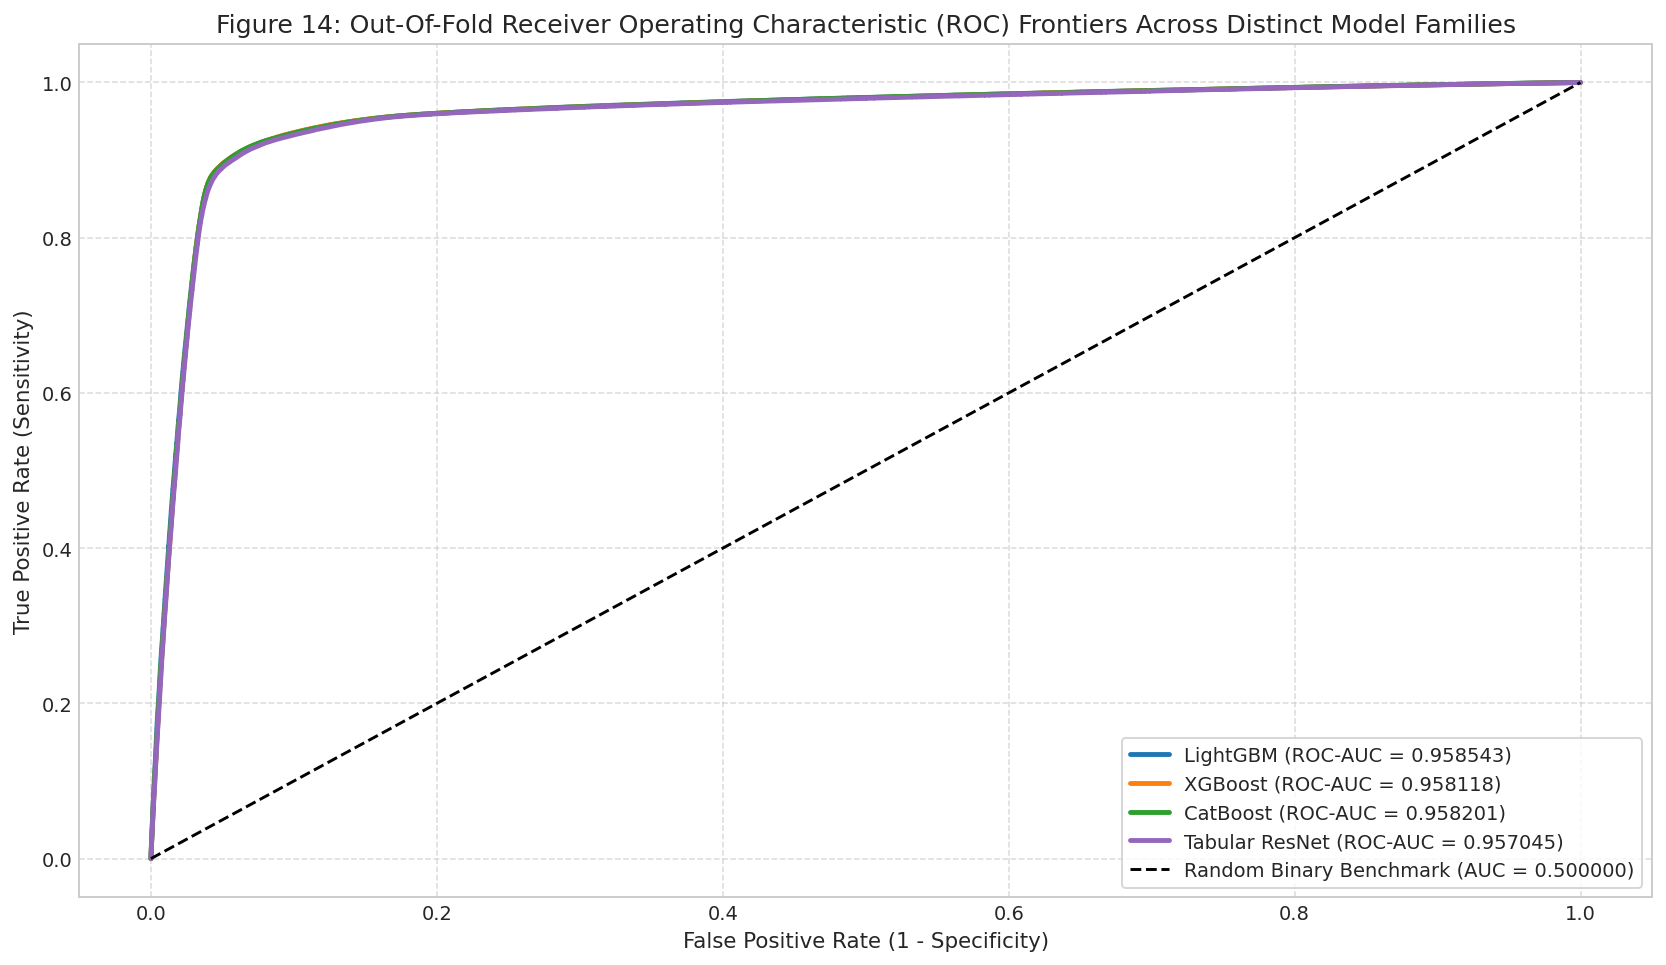

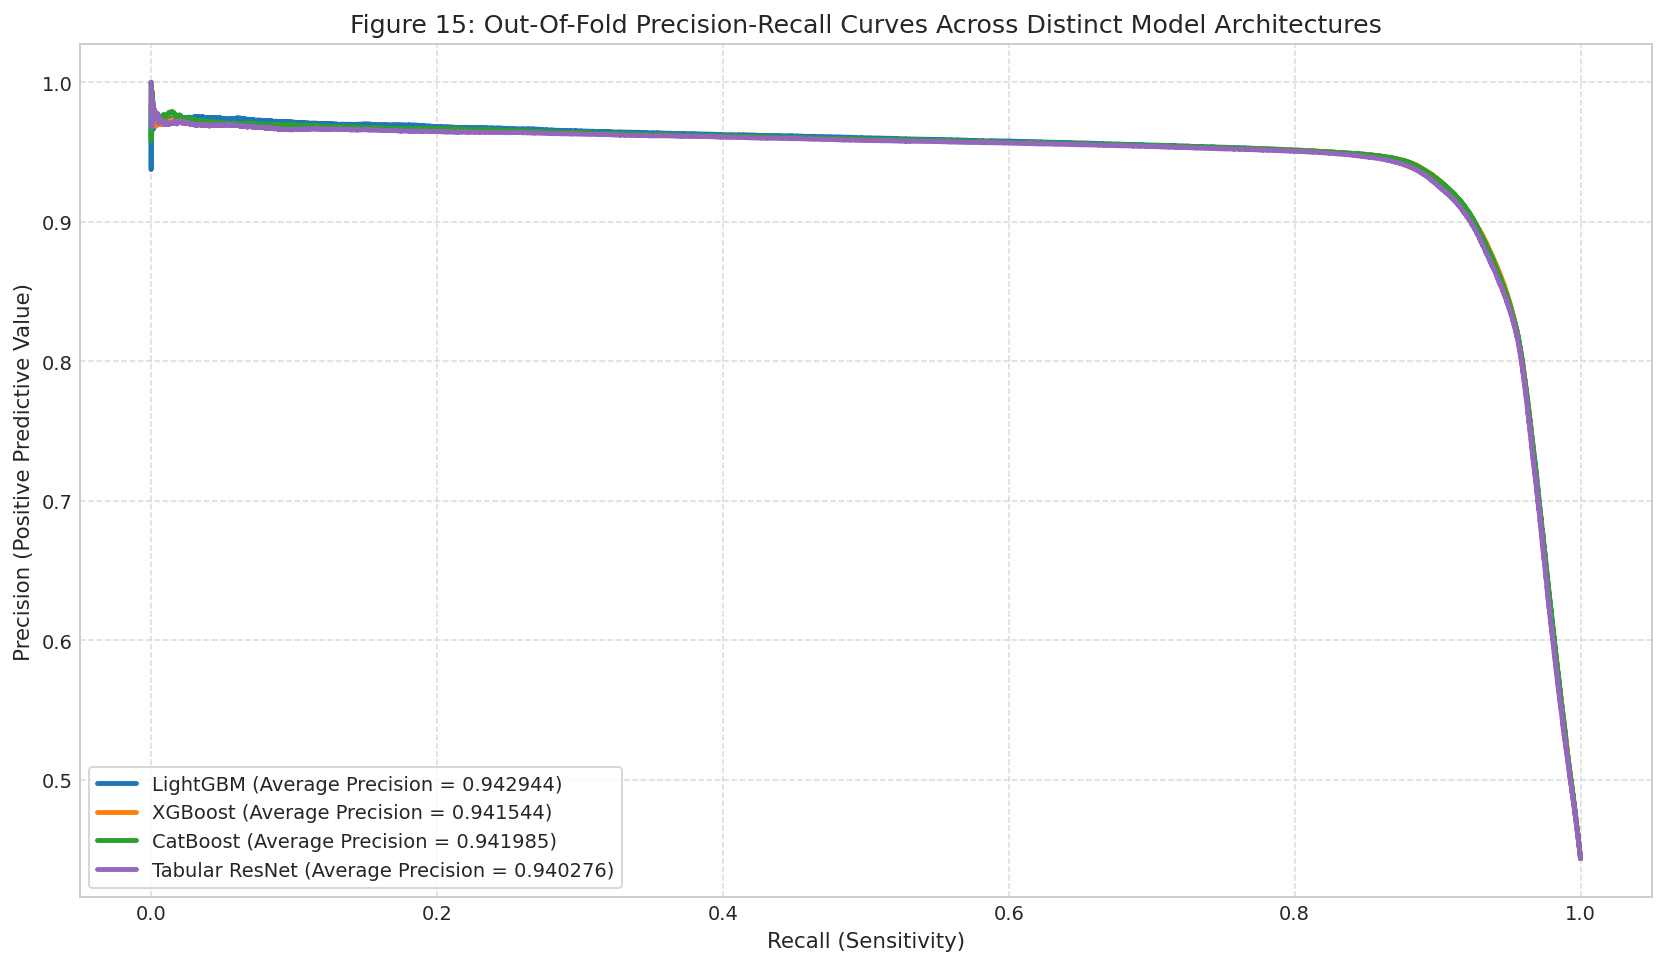

In [16]:
# Plot 14: Model-by-Model Out-Of-Fold ROC Curves
fig, ax = plt.subplots(figsize=(12, 7))

model_specs = [
    ('LightGBM', oof_lgb, '#1f77b4'),
    ('XGBoost', oof_xgb, '#ff7f0e'),
    ('CatBoost', oof_cb, '#2ca02c'),
    ('Tabular ResNet', oof_nn, '#9467bd')
]

for name, preds, color in model_specs:
    fpr, tpr, _ = roc_curve(train_engineered['target'], preds)
    auc_score = roc_auc_score(train_engineered['target'], preds)
    ax.plot(fpr, tpr, label=f'{name} (ROC-AUC = {auc_score:.6f})', color=color, linewidth=2.5)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Binary Benchmark (AUC = 0.500000)')
ax.set_title('Figure 14: Out-Of-Fold Receiver Operating Characteristic (ROC) Frontiers Across Distinct Model Families')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.legend(loc='lower right', frameon=True)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot 15: Precision-Recall Curves
fig, ax = plt.subplots(figsize=(12, 7))

for name, preds, color in model_specs:
    precision_pts, recall_pts, _ = precision_recall_curve(train_engineered['target'], preds)
    ap_score = average_precision_score(train_engineered['target'], preds)
    ax.plot(recall_pts, precision_pts, label=f'{name} (Average Precision = {ap_score:.6f})', color=color, linewidth=2.5)

ax.set_title('Figure 15: Out-Of-Fold Precision-Recall Curves Across Distinct Model Architectures')
ax.set_xlabel('Recall (Sensitivity)')
ax.set_ylabel('Precision (Positive Predictive Value)')
ax.legend(loc='lower left', frameon=True)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


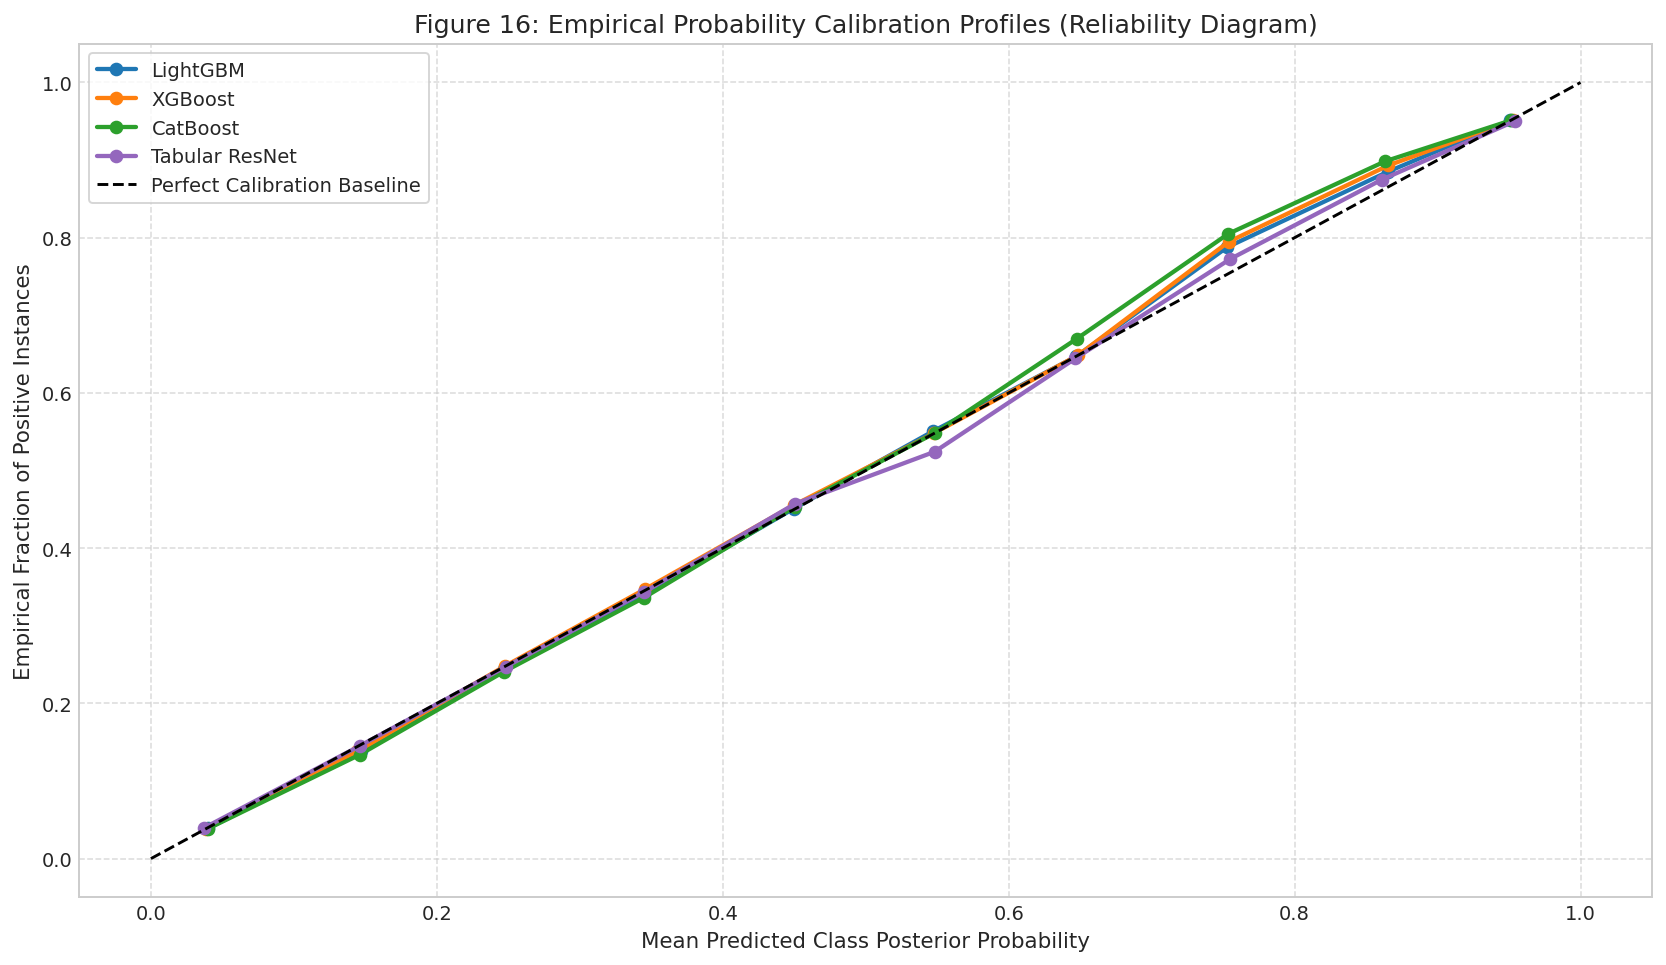

In [17]:
# Plot 16: Probability Calibration Profiles
fig, ax = plt.subplots(figsize=(12, 7))

for name, preds, color in model_specs:
    fraction_pos, mean_pred = calibration_curve(train_engineered['target'], preds, n_bins=10, strategy='uniform')
    ax.plot(mean_pred, fraction_pos, marker='o', markersize=6, label=f'{name}', color=color, linewidth=2.2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect Calibration Baseline')
ax.set_title('Figure 16: Empirical Probability Calibration Profiles (Reliability Diagram)')
ax.set_xlabel('Mean Predicted Class Posterior Probability')
ax.set_ylabel('Empirical Fraction of Positive Instances')
ax.legend(loc='upper left', frameon=True)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


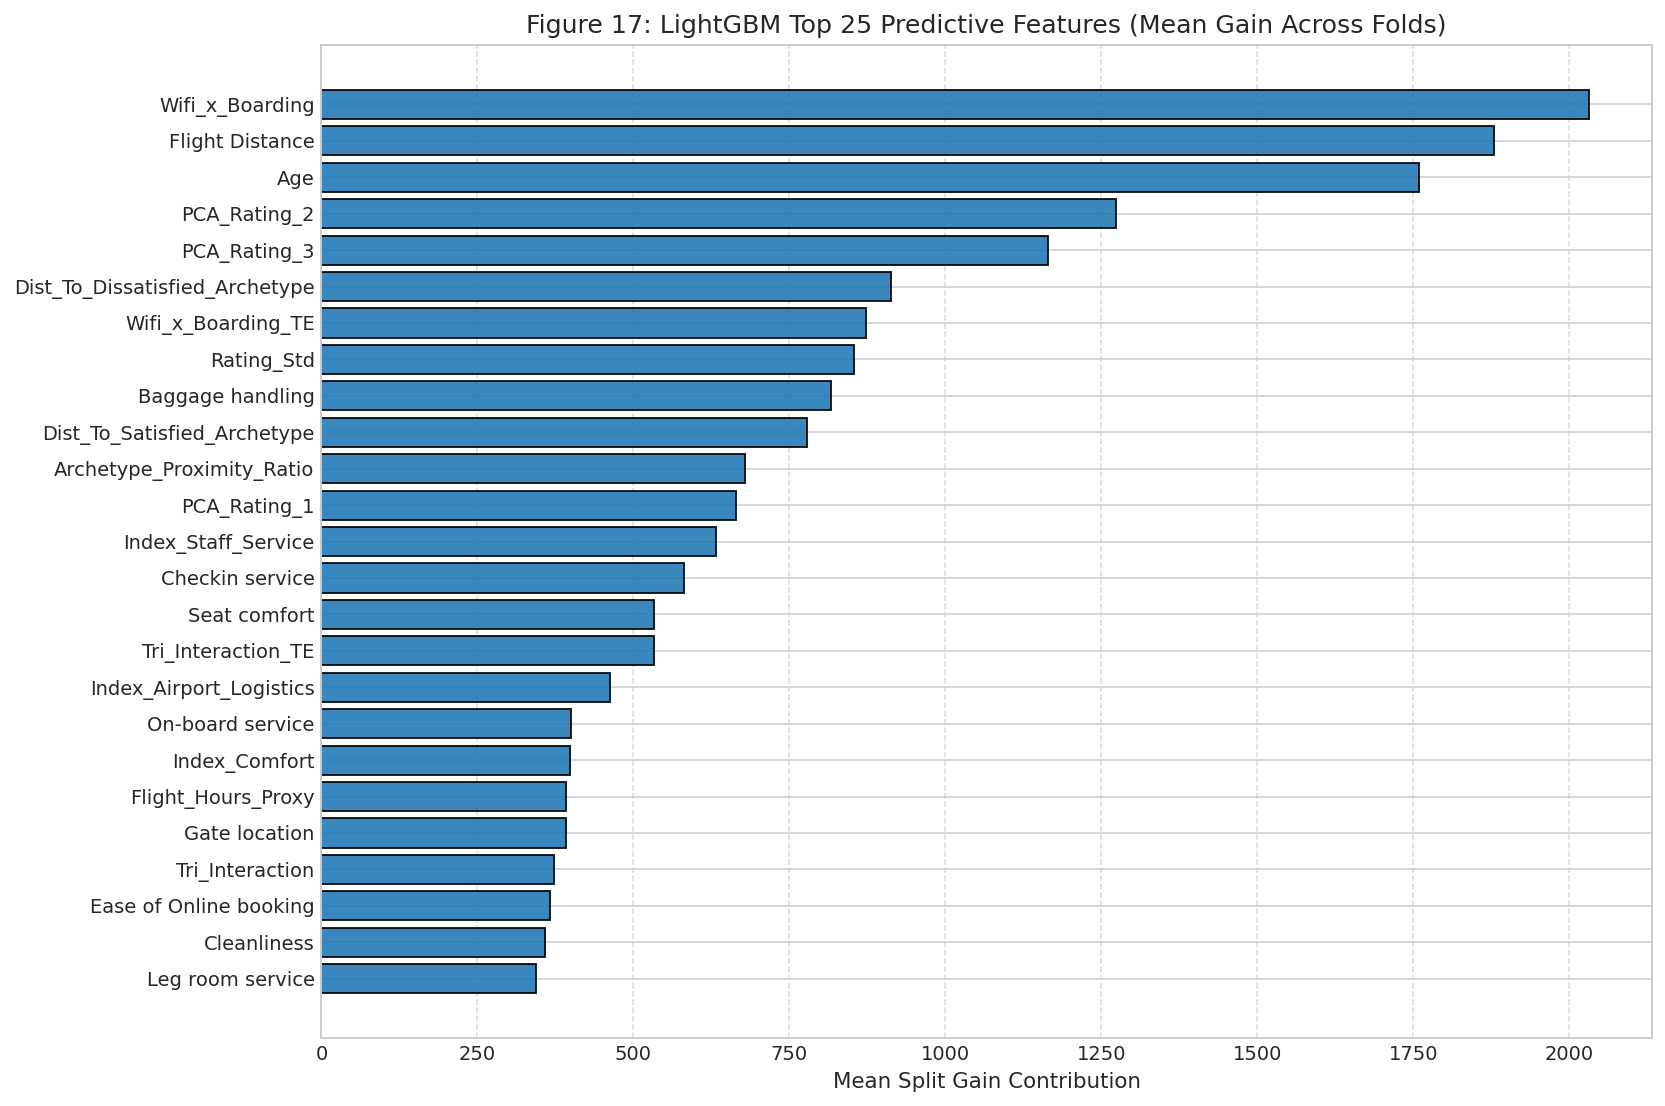

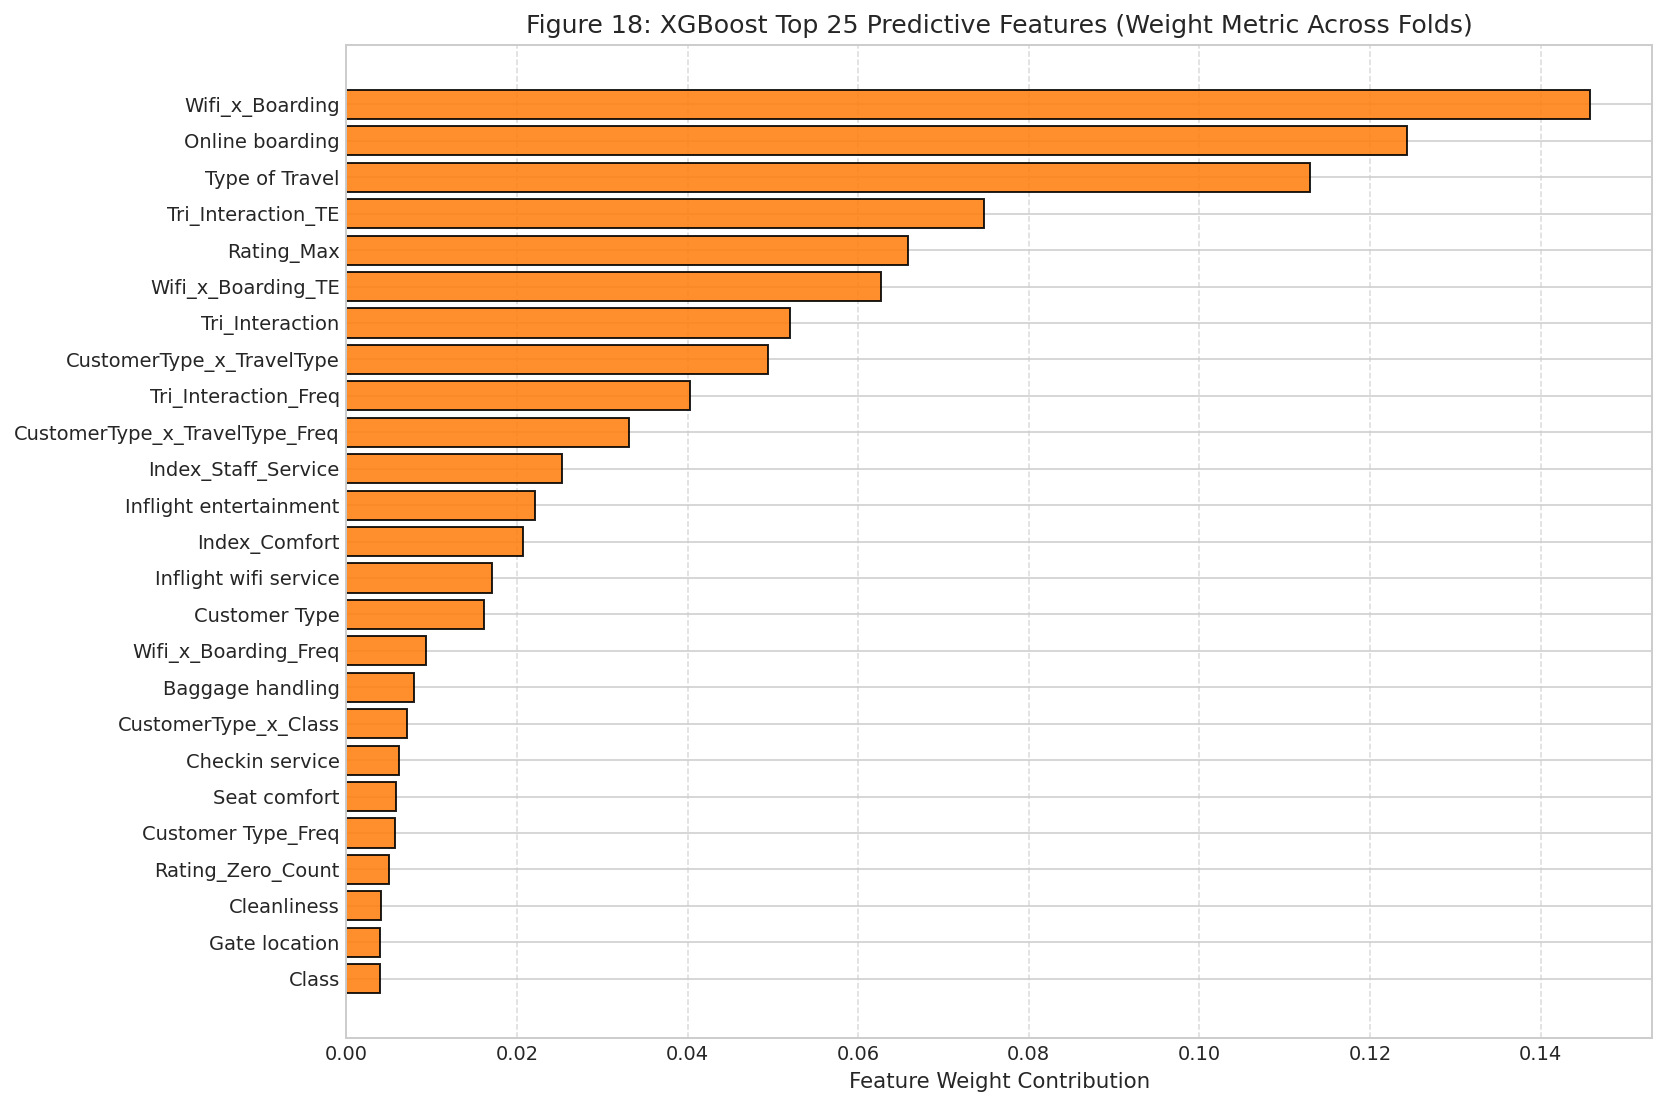

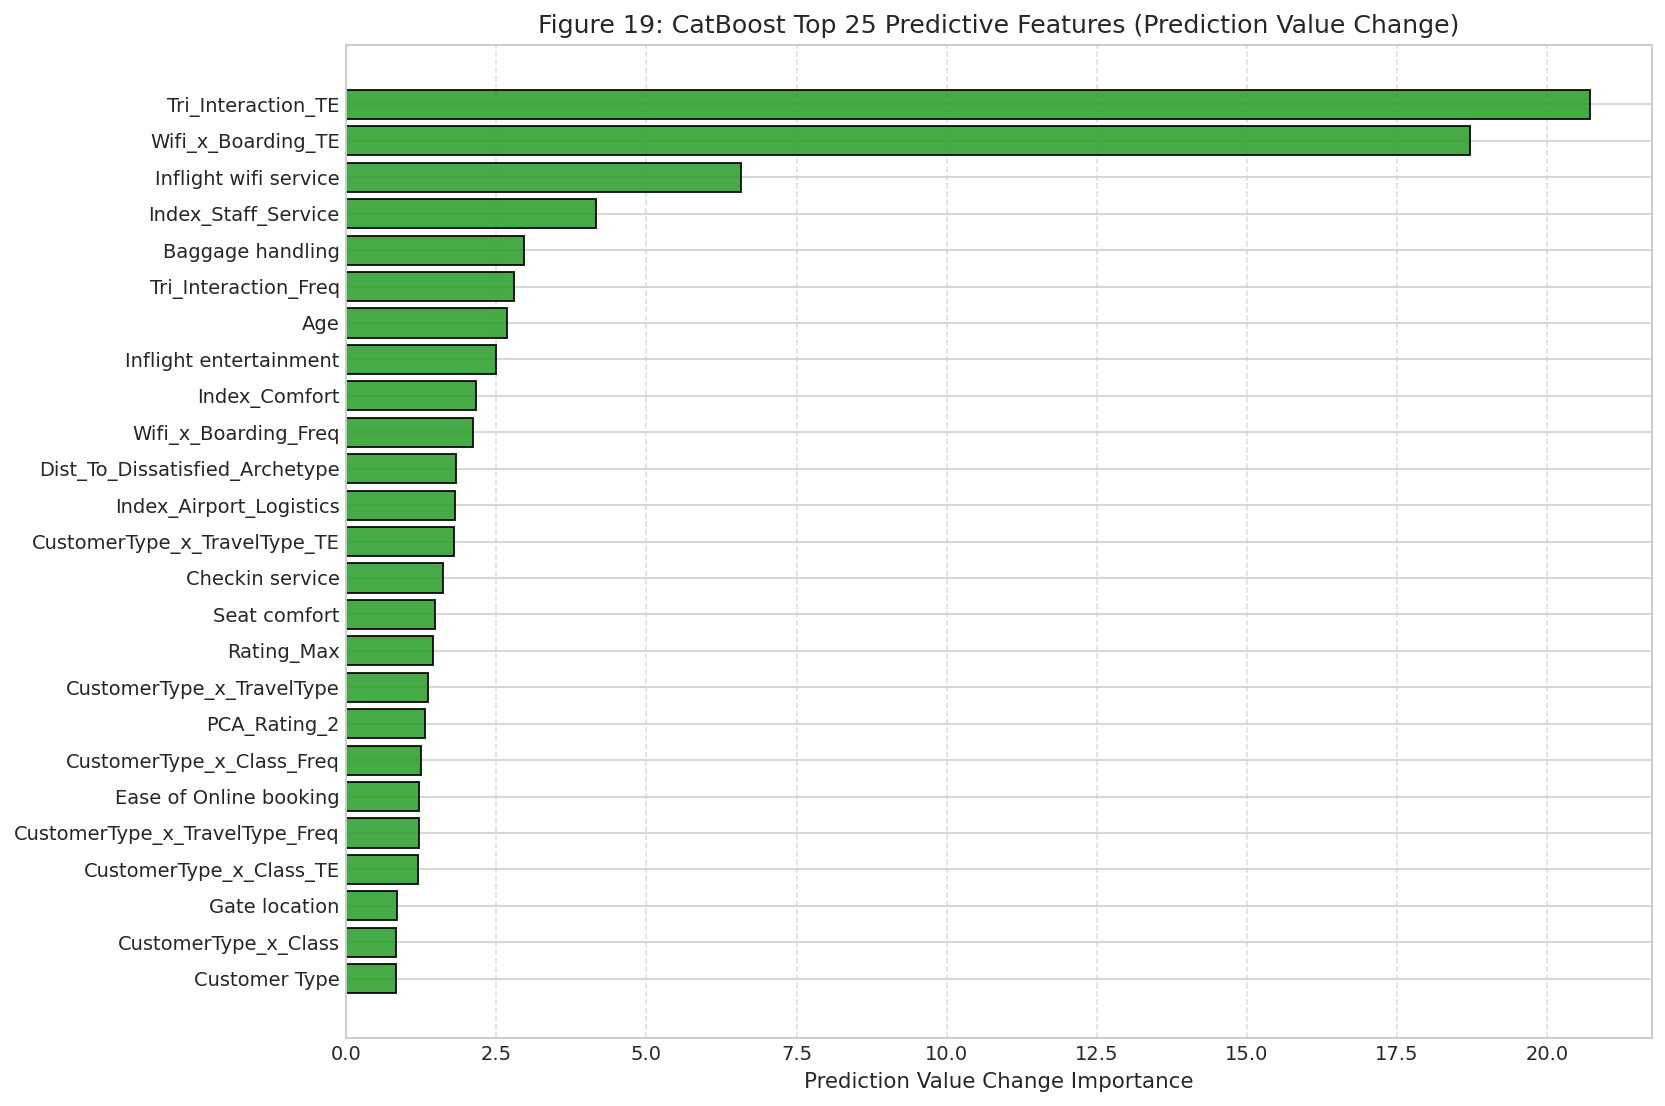

In [18]:
# Plot 17: LightGBM Top 25 Predictive Features
top25_lgb_indices = np.argsort(lgb_feature_importances)[-25:]
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(np.array(model_features)[top25_lgb_indices], lgb_feature_importances[top25_lgb_indices], color='#1f77b4', edgecolor='black', alpha=0.88)
ax.set_xlabel('Mean Split Gain Contribution')
ax.set_title('Figure 17: LightGBM Top 25 Predictive Features (Mean Gain Across Folds)')
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot 18: XGBoost Top 25 Predictive Features
top25_xgb_indices = np.argsort(xgb_feature_importances)[-25:]
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(np.array(model_features)[top25_xgb_indices], xgb_feature_importances[top25_xgb_indices], color='#ff7f0e', edgecolor='black', alpha=0.88)
ax.set_xlabel('Feature Weight Contribution')
ax.set_title('Figure 18: XGBoost Top 25 Predictive Features (Weight Metric Across Folds)')
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot 19: CatBoost Top 25 Predictive Features
top25_cb_indices = np.argsort(cb_feature_importances)[-25:]
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(np.array(model_features)[top25_cb_indices], cb_feature_importances[top25_cb_indices], color='#2ca02c', edgecolor='black', alpha=0.88)
ax.set_xlabel('Prediction Value Change Importance')
ax.set_title('Figure 19: CatBoost Top 25 Predictive Features (Prediction Value Change)')
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


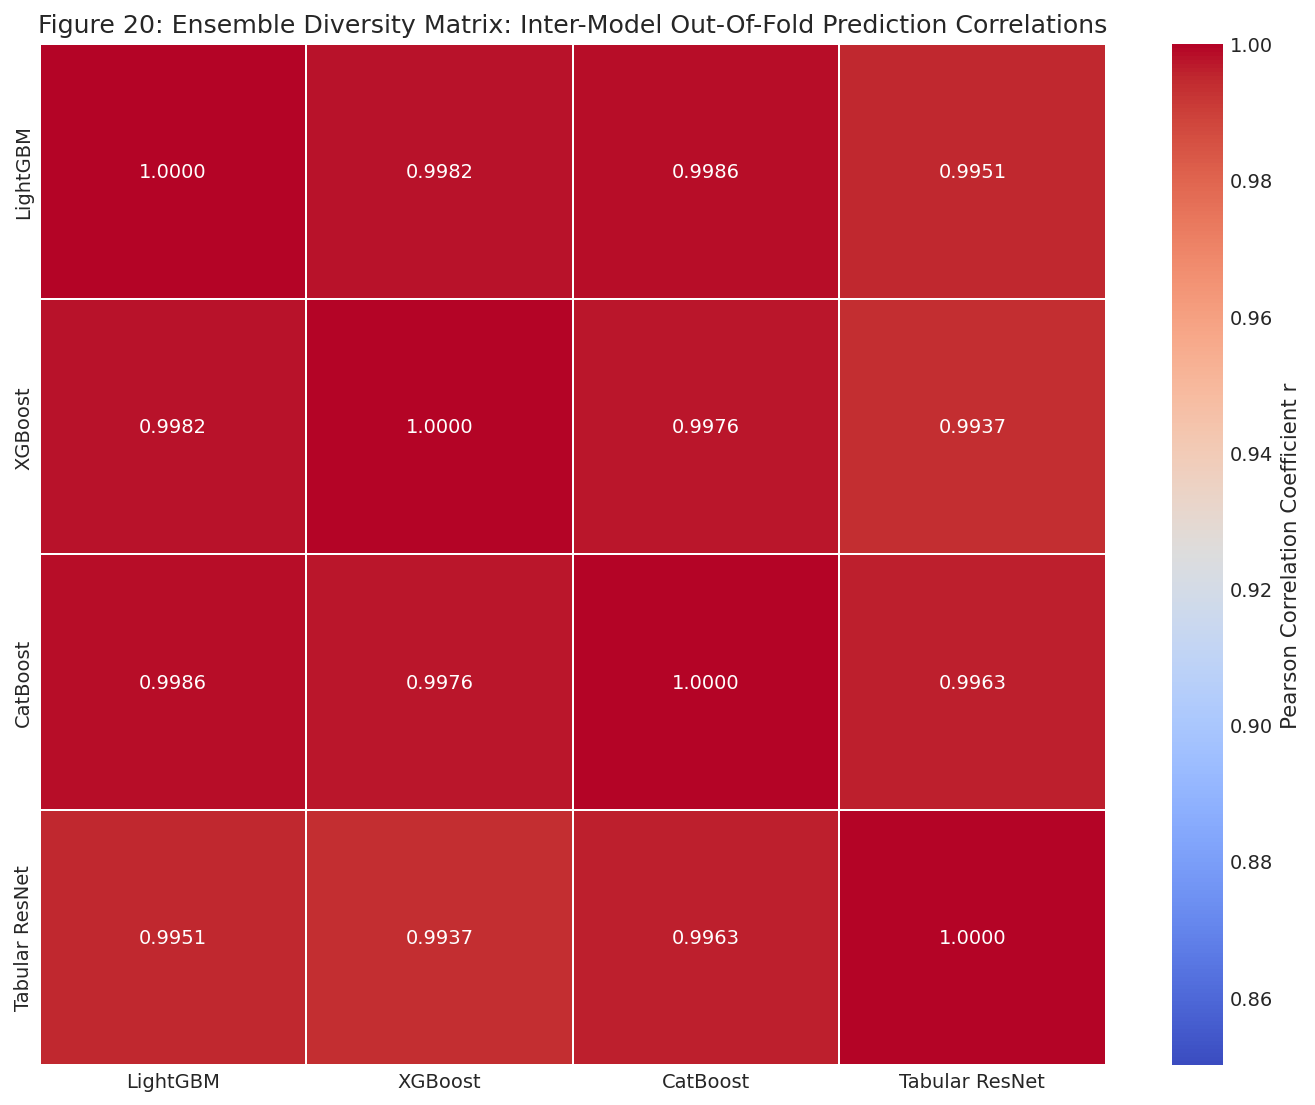

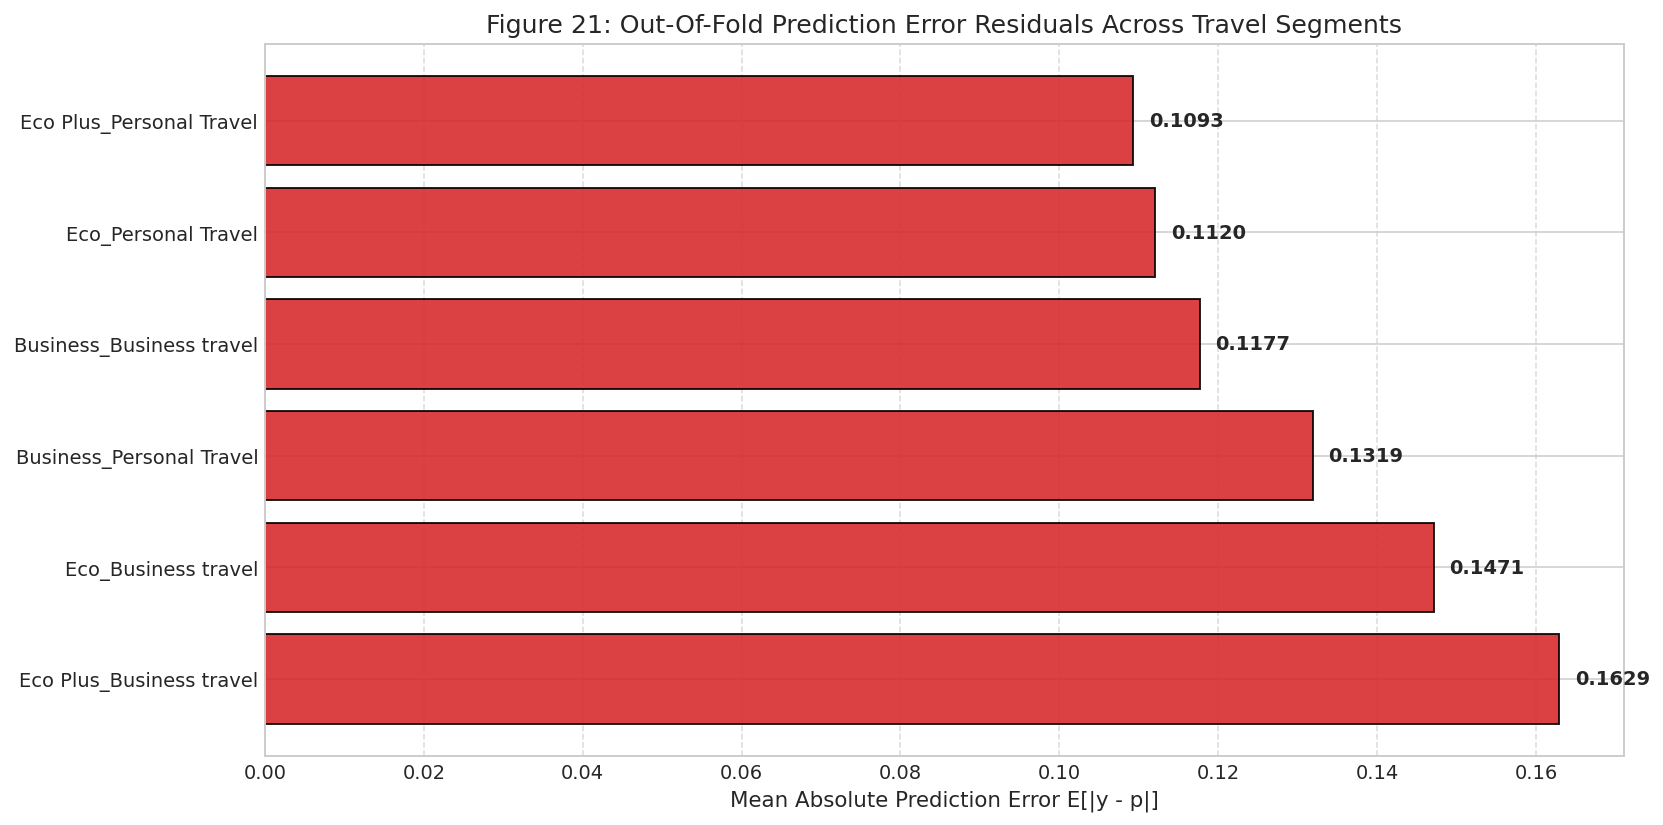

In [19]:
oof_predictions_df = pd.DataFrame({
    'LightGBM': oof_lgb,
    'XGBoost': oof_xgb,
    'CatBoost': oof_cb,
    'Tabular ResNet': oof_nn
})

# Plot 20: Out-of-Fold Prediction Correlation Matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(oof_predictions_df.corr(), annot=True, fmt='.4f', cmap='coolwarm', vmin=0.85, vmax=1.0,
            linewidths=1.0, linecolor='white', cbar_kws={'label': 'Pearson Correlation Coefficient r'}, ax=ax)
ax.set_title('Figure 20: Ensemble Diversity Matrix: Inter-Model Out-Of-Fold Prediction Correlations')
plt.tight_layout()
plt.show()

# Plot 21: Error Residual Distribution Across Passenger Segments
train_engineered['Mean_Abs_Error'] = np.abs(train_engineered['target'] - oof_lgb)
segment_errors = train_engineered.groupby('Class_x_TravelType')['Mean_Abs_Error'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(segment_errors.index.astype(str), segment_errors.values, color='#d62728', edgecolor='black', alpha=0.88)
ax.set_xlabel('Mean Absolute Prediction Error E[|y - p|]')
ax.set_title('Figure 21: Out-Of-Fold Prediction Error Residuals Across Travel Segments')
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.002, bar.get_y() + bar.get_height()/2.0, f"{w:.4f}", ha='left', va='center', fontweight='bold', fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# 9. Metamodeling & ROC-AUC Constrained Ensemble Optimization

To find the optimal convex combination of model predictions, we formulate an optimization problem constrained on the probability simplex $\Delta^K$:

$$\mathbf{w}^* = \arg\max_{\mathbf{w} \in \Delta^K} \text{ROC-AUC}\left(\sum_{k=1}^K w_k \hat{\mathbf{p}}_k, \mathbf{y}\right) \quad \text{subject to} \quad \sum_{k=1}^K w_k = 1, \quad w_k \ge 0$$

where $\hat{\mathbf{p}}_k \in [0, 1]^N$ represents the out-of-fold probability vector from the $k$-th architecture.

In addition to linear convex combination, we evaluate **Rank Averaging**, an order-statistic ensembling technique:

$$\hat{\mathbf{p}}_{\text{rank}} = \sum_{k=1}^K w_k \cdot \frac{\text{Rank}(\hat{\mathbf{p}}_k)}{N}$$

Because ROC-AUC is purely rank-dependent, rank transformation maps disparate probability scales to a uniform margin $[0, 1]$, mitigating calibration discrepancies between gradient-boosted trees and neural networks.

In [20]:
def negative_auc_objective(weights):
    w = np.array(weights)
    w = w / np.sum(w)
    blended_probs = (w[0] * oof_lgb +
                     w[1] * oof_xgb +
                     w[2] * oof_cb +
                     w[3] * oof_nn)
    return -roc_auc_score(train_engineered['target'], blended_probs)

initial_guess = [0.35, 0.35, 0.20, 0.10]
simplex_bounds = [(0.0, 1.0) for _ in range(4)]
simplex_constraint = {'type': 'eq', 'fun': lambda w: 1.0 - sum(w)}

opt_result = minimize(
    negative_auc_objective,
    initial_guess,
    method='SLSQP',
    bounds=simplex_bounds,
    constraints=simplex_constraint
)

optimal_weights = opt_result.x / np.sum(opt_result.x)
model_names = ['LightGBM', 'XGBoost', 'CatBoost', 'Tabular ResNet']

print("Constrained Convex Optimization Results (Simplex Weights):")
for name, w in zip(model_names, optimal_weights):
    print(f"  {name:15s}: Weight = {w:.5f} ({w*100:.2f}%)")

# Evaluate Linear Probability Blending
oof_linear_blend = (optimal_weights[0] * oof_lgb +
                    optimal_weights[1] * oof_xgb +
                    optimal_weights[2] * oof_cb +
                    optimal_weights[3] * oof_nn)
auc_linear_blend = roc_auc_score(train_engineered['target'], oof_linear_blend)
print(f"\nFinal Convex Linear Blended Out-Of-Fold ROC-AUC: {auc_linear_blend:.6f}")

# Evaluate Rank Averaging
oof_rank_blend = (stats.rankdata(oof_lgb) * optimal_weights[0] +
                  stats.rankdata(oof_xgb) * optimal_weights[1] +
                  stats.rankdata(oof_cb) * optimal_weights[2] +
                  stats.rankdata(oof_nn) * optimal_weights[3]) / len(oof_lgb)
auc_rank_blend = roc_auc_score(train_engineered['target'], oof_rank_blend)
print(f"Final Rank-Averaged Out-Of-Fold ROC-AUC:        {auc_rank_blend:.6f}")

# Select regime optimizing the empirical ROC-AUC metric
if auc_linear_blend >= auc_rank_blend:
    selected_ensemble_regime = 'linear_convex_blend'
    final_test_predictions = (optimal_weights[0] * test_preds_lgb +
                              optimal_weights[1] * test_preds_xgb +
                              optimal_weights[2] * test_preds_cb +
                              optimal_weights[3] * test_preds_nn)
    final_oof_predictions = oof_linear_blend
    optimal_oof_auc = auc_linear_blend
else:
    selected_ensemble_regime = 'rank_average_ensemble'
    final_test_predictions = (stats.rankdata(test_preds_lgb) * optimal_weights[0] +
                              stats.rankdata(test_preds_xgb) * optimal_weights[1] +
                              stats.rankdata(test_preds_cb) * optimal_weights[2] +
                              stats.rankdata(test_preds_nn) * optimal_weights[3]) / len(test_preds_lgb)
    final_oof_predictions = oof_rank_blend
    optimal_oof_auc = auc_rank_blend

print(f"Optimal Metamodel Regime Selected: {selected_ensemble_regime.upper()} (OOF ROC-AUC = {optimal_oof_auc:.6f})")


Constrained Convex Optimization Results (Simplex Weights):
  LightGBM       : Weight = 0.35006 (35.01%)
  XGBoost        : Weight = 0.34997 (35.00%)
  CatBoost       : Weight = 0.20003 (20.00%)
  Tabular ResNet : Weight = 0.09994 (9.99%)

Final Convex Linear Blended Out-Of-Fold ROC-AUC: 0.958709
Final Rank-Averaged Out-Of-Fold ROC-AUC:        0.958757
Optimal Metamodel Regime Selected: RANK_AVERAGE_ENSEMBLE (OOF ROC-AUC = 0.958757)


# 10. Test Set Inference, Submission Verification, & Probability Density Alignment

Prior to writing the final submission artifact, we verify test prediction integrity:
1. Dimensional equality: The test submission row count must strictly match `sample_submission.csv` ($299{,}844$).
2. Domain closure: Probabilities must fall strictly within the unit interval $[0, 1]$.
3. Missingness check: No `NaN` or infinite values.
4. Probability Density Alignment: We verify that the probability density function of unseen test predictions closely matches the out-of-fold empirical distribution.

Submission verified and saved to 'submission.csv'.
Submission Dimensions: 299,844 rows x 2 columns

First 10 Predicted Rows:


,id,satisfaction
0,699635,0.529098
1,699636,0.608106
2,699637,0.642688
3,699638,0.418318
4,699639,0.368146
5,699640,0.939257
6,699641,0.162069
7,699642,0.685558
8,699643,0.959006
9,699644,0.220223



Test Prediction Probability Distribution Summary:


count    299844.000000
mean          0.500002
std           0.285547
min           0.000086
25%           0.244898
50%           0.501263
75%           0.755726
max           0.999927
Name: satisfaction, dtype: float64

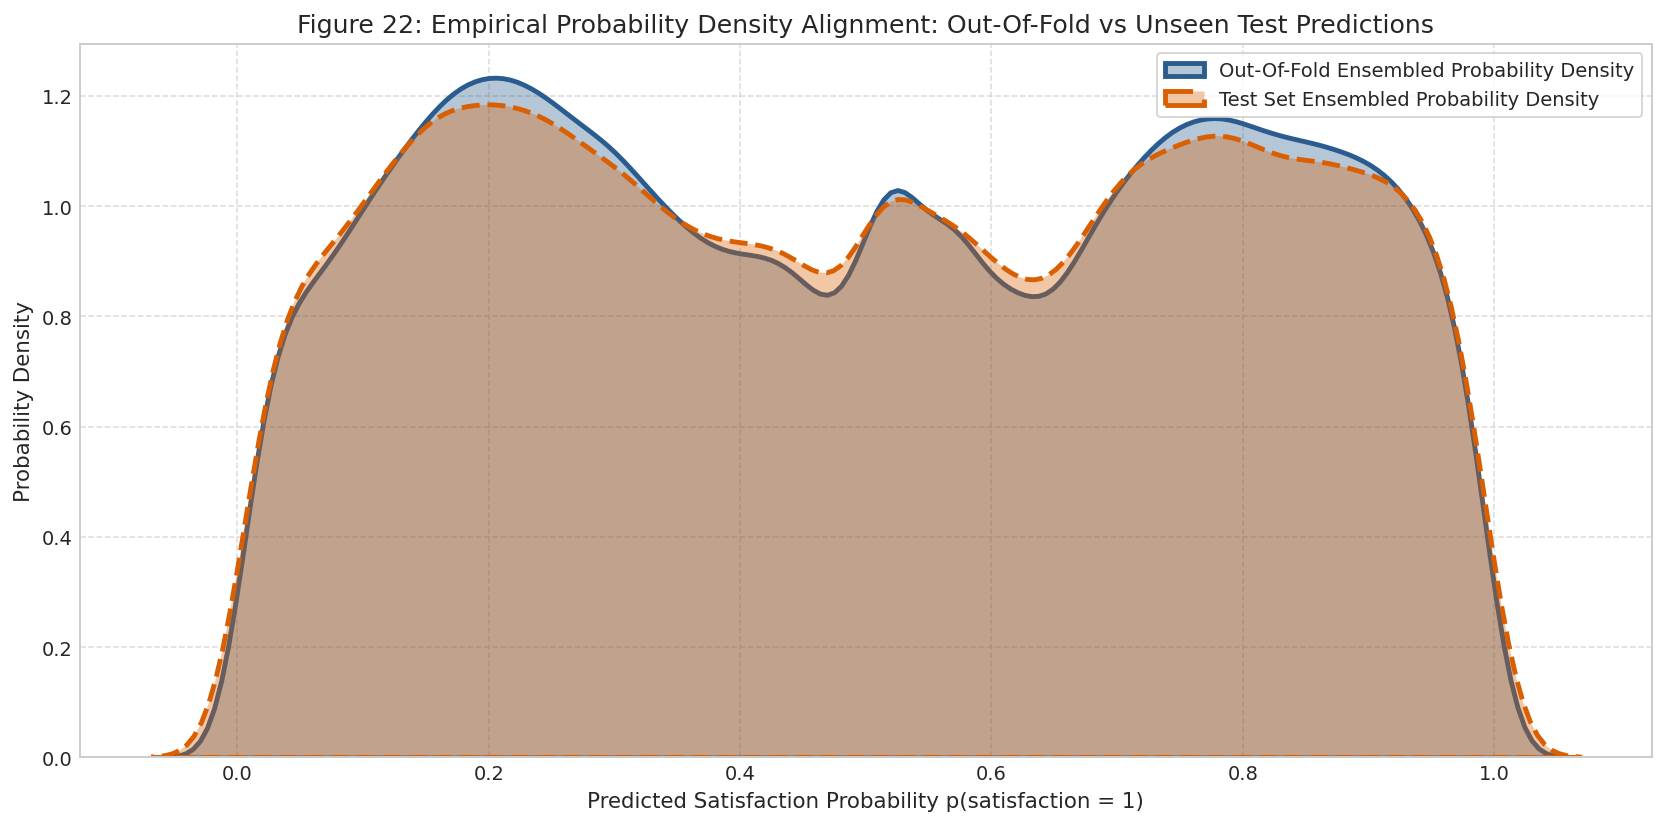

In [21]:
# Construct and format submission dataframe
submission_df = pd.DataFrame({
    'id': test_df['id'],
    'satisfaction': final_test_predictions
})

# Rigorous Sanity Checks
assert len(submission_df) == len(sample_sub_df), f"Submission row length error: Expected {len(sample_sub_df)}, observed {len(submission_df)}"
assert submission_df['satisfaction'].isnull().sum() == 0, "Submission contains null/NaN values."
assert (submission_df['satisfaction'] >= 0.0).all() and (submission_df['satisfaction'] <= 1.0).all(), "Predictions violate probability boundary [0, 1]."

# Write verified submission file to disk
submission_df.to_csv('submission.csv', index=False)
print("Submission verified and saved to 'submission.csv'.")
print(f"Submission Dimensions: {submission_df.shape[0]:,} rows x {submission_df.shape[1]} columns")

print("\nFirst 10 Predicted Rows:")
display(submission_df.head(10))

print("\nTest Prediction Probability Distribution Summary:")
display(submission_df['satisfaction'].describe())

# Plot 22: OOF vs Test Prediction Probability Density Alignment
fig, ax = plt.subplots(figsize=(12, 6))
sns.kdeplot(final_oof_predictions, label='Out-Of-Fold Ensembled Probability Density',
            color='#2b5c8f', fill=True, alpha=0.35, linewidth=2.5, ax=ax)
sns.kdeplot(submission_df['satisfaction'], label='Test Set Ensembled Probability Density',
            color='#d95f02', fill=True, alpha=0.35, linewidth=2.5, linestyle='--', ax=ax)
ax.set_title('Figure 22: Empirical Probability Density Alignment: Out-Of-Fold vs Unseen Test Predictions')
ax.set_xlabel('Predicted Satisfaction Probability p(satisfaction = 1)')
ax.set_ylabel('Probability Density')
ax.legend(frameon=True)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
